 # Component Model Analysis



 This notebook demonstrates how to use the component analysis utilities to:

 1. Calculate component frequencies and importance scores

 2. Analyze cosine similarities between components

 3. Visualize the results

In [1]:
# Imports
import torch
import os
from spd.models.component_model import ComponentModel
from spd.models.components import EmbeddingComponent, Gate, GateMLP, LinearComponent
from spd.data import DatasetConfig, create_data_loader
from transformers import AutoTokenizer

# Import our analysis utilities
from analysis_utils import (
    ComponentAnalysisResults,
    calculate_component_frequency,
    calculate_weight_sim_importance,
    calculate_encoder_decoder_norms,
    calculate_alive_dead_masks,
    calculate_cosine_similarities,
    calculate_all_mmcs_metrics
)
from plotting_utils import (
    plot_encoder_decoder_norms,
    plot_frequency_vs_weight_sim,
    plot_weight_sim_histogram,
    plot_mmcs_histograms,
    plot_alive_frequency_relationships,
    plot_correlation_summary
)


/workspace/Stochastic_Parameter_Decomposition/spd_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# model_dir = "out/clamp=1.0e+00_stoch=1.0e-03_all=1.0e+00_fill=True_rem_ded=False_fil_scalar=1.0_faith=1.0/"
model_dir = "out/no_stoch/"
steps = 50000
model_path = os.path.join(model_dir, f"model_{steps}.pth")
config_path = os.path.join(model_dir, f"final_config.yaml")

# Load model
model, config, out_dir = ComponentModel.from_pretrained(model_path)
model.to(device)
model.requires_grad_(False)

# Load tokenizer
model_name = "roneneldan/TinyStories-1M"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token


Filler comp: False


 ## Setup Data Loader

In [3]:
# Create evaluation data loader
# test_split = "train[:100]"
batch_size = 32
eval_data_config = DatasetConfig(
    name=config.task_config.dataset_name,
    hf_tokenizer_path=config.pretrained_model_name_hf,
    split=config.task_config.eval_data_split,
    # split=test_split,
    # split=config.task_config.eval_data_split,
    n_ctx=config.task_config.max_seq_len,
    is_tokenized=False,
    streaming=False,
    column_name=config.task_config.column_name,
)
eval_loader, _ = create_data_loader(
    dataset_config=eval_data_config,
    batch_size=batch_size,
    buffer_size=config.task_config.buffer_size,
    global_seed=config.seed,
    ddp_rank=0,
    ddp_world_size=1,
)

print(f"Eval dataset name: {eval_data_config.name}")
print(f"Split: {eval_data_config.split}")
print(f"Number of batches: {len(eval_loader)}")


Eval dataset name: roneneldan/TinyStories
Split: validation[:10_000]
Number of batches: 998


 ## Extract Components and Gates

In [4]:
# Extract gates and components
module_comp = [key.replace('-', '.') for key in model.components.keys()]

gates = {
    k.removeprefix("gates.").replace("-", "."): v 
    for k, v in model.gates.items()
}

components = {
    k.removeprefix("components.").replace("-", "."): v 
    for k, v in model.components.items()
}

As = {module_name: components[module_name].A for module_name in components}

# Target module for analysis
module_name = config.target_module_patterns[0]
num_components = config.C

print(f"Analyzing module: {module_name}")
print(f"Number of components: {num_components}")


Analyzing module: transformer.h.3.mlp.c_fc
Number of components: 1200


 ## Calculate Component Statistics

In [5]:
# Initialize results container
results = ComponentAnalysisResults(
    module_name=module_name,
    num_components=num_components
)

# Calculate component frequency
print("Calculating component frequencies...")
results.frequency = calculate_component_frequency(
    model=model,
    eval_loader=eval_loader,
    components=components,
    As=As,
    gates=gates,
    module_comp=module_comp,
    module_name=module_name,
    device=device
)

# Calculate weight similarity importance
print("Calculating weight similarity importance...")
results.weight_sim_importance = calculate_weight_sim_importance(
    components=components,
    model=model,
    num_components=num_components,
    device=device
)

# Calculate encoder/decoder norms
print("Calculating encoder/decoder norms...")
results.enc_norms, results.dec_norms = calculate_encoder_decoder_norms(
    components=components,
    module_name=module_name
)

# Calculate alive/dead masks
results.alive_mask, results.dead_mask = calculate_alive_dead_masks(
    frequency=results.frequency,
    threshold=0
)

print(f"Alive components: {results.alive_mask.sum().item()}")
print(f"Dead components: {results.dead_mask.sum().item()}")


Calculating component frequencies...


Calculating component frequencies: 100%|██████████| 998/998 [00:09<00:00, 104.64it/s]


Calculating weight similarity importance...


Calculating weight sim importance: 100%|██████████| 1200/1200 [00:00<00:00, 3054.92it/s]


Calculating encoder/decoder norms...
Alive components: 324
Dead components: 876


 ## Calculate Cosine Similarities

In [6]:
# Calculate cosine similarities
print("Calculating cosine similarities...")
results.cosine_similarities = calculate_cosine_similarities(
    components=components,
    module_name=module_name,
    alive_mask=results.alive_mask,
    dead_mask=results.dead_mask
)

# Calculate MMCS metrics
print("Calculating MMCS metrics...")
results.mmcs_metrics = calculate_all_mmcs_metrics(
    components=components,
    module_name=module_name,
    alive_mask=results.alive_mask,
    dead_mask=results.dead_mask
)

# Print summary statistics
print("\nMMCS Summary (Max):")
for key, value in results.mmcs_metrics['max'].items():
    if key.endswith('_mean'):
        print(f"  {key}: {value:.3f}")

print("\nMMCS Summary (Min):")
for key, value in results.mmcs_metrics['min'].items():
    if key.endswith('_mean'):
        print(f"  {key}: {value:.3f}")


Calculating cosine similarities...
Calculating MMCS metrics...

MMCS Summary (Max):
  mmcs_a_a_enc_mean: 0.062
  mmcs_a_a_dec_mean: 0.264
  mmcs_d_d_enc_mean: 0.031
  mmcs_d_d_dec_mean: 0.167
  mmcs_d_a_enc_mean: 0.044
  mmcs_d_a_dec_mean: 0.209

MMCS Summary (Min):
  mmcs_a_a_enc_mean: -0.062
  mmcs_a_a_dec_mean: -0.268
  mmcs_d_d_enc_mean: -0.031
  mmcs_d_d_dec_mean: -0.166
  mmcs_d_a_enc_mean: -0.044
  mmcs_d_a_dec_mean: -0.211


 ## Visualizations

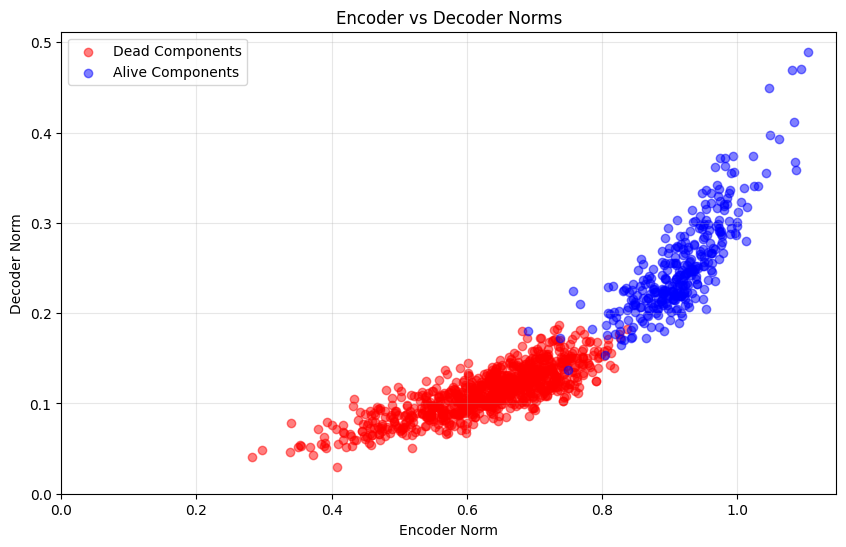

In [7]:
# Plot encoder vs decoder norms
fig1 = plot_encoder_decoder_norms(
    enc_norms=results.enc_norms,
    dec_norms=results.dec_norms,
    alive_mask=results.alive_mask,
    dead_mask=results.dead_mask,
    same_scale=False
)
fig1.show()


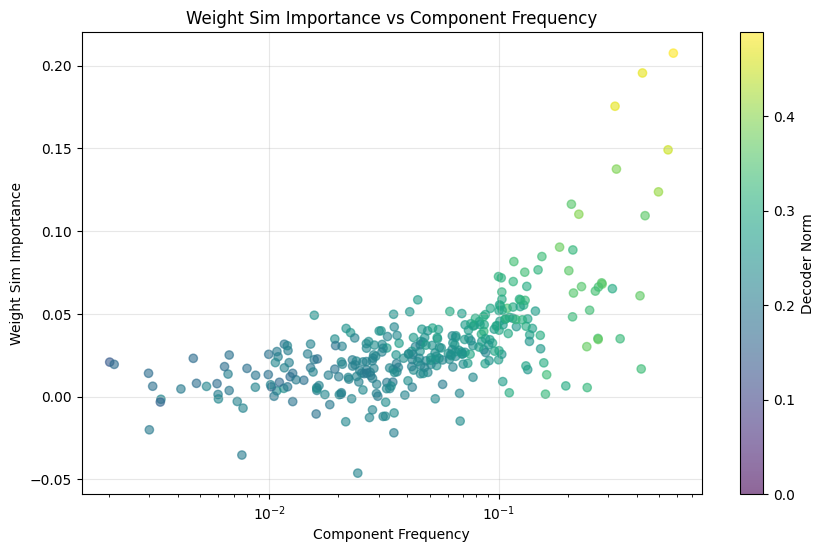

In [8]:
# Plot frequency vs weight sim importance
fig2 = plot_frequency_vs_weight_sim(
    frequency=results.frequency,
    weight_sim_importance=results.weight_sim_importance,
    dec_norms=results.dec_norms
)
fig2.show()


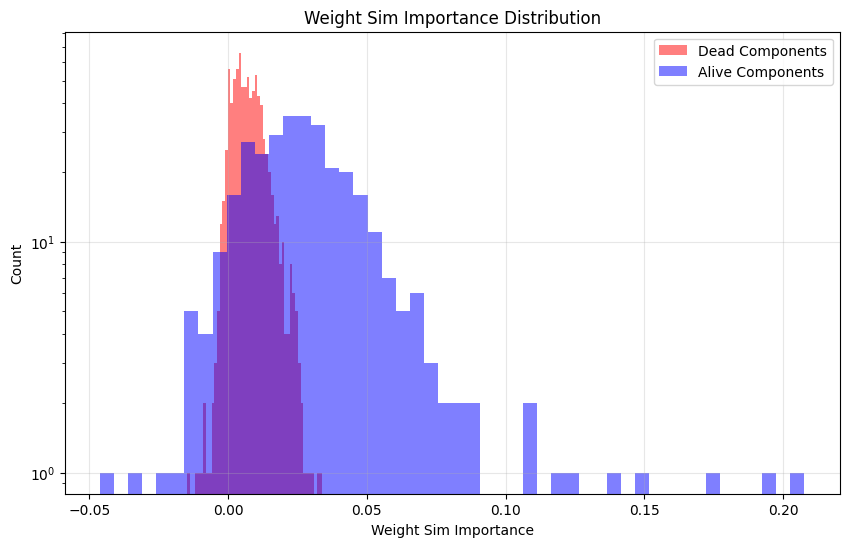

In [9]:
# Plot weight sim importance histogram
fig3 = plot_weight_sim_histogram(
    weight_sim_importance=results.weight_sim_importance,
    alive_mask=results.alive_mask
)
fig3.show()


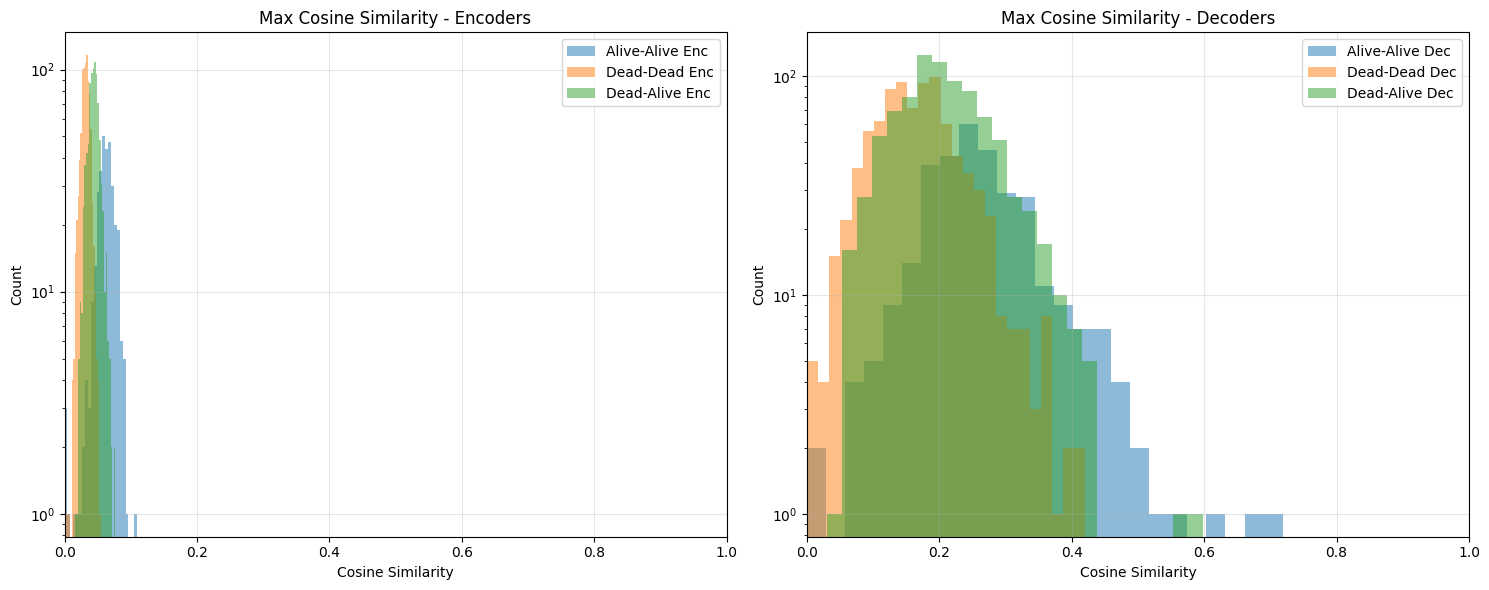

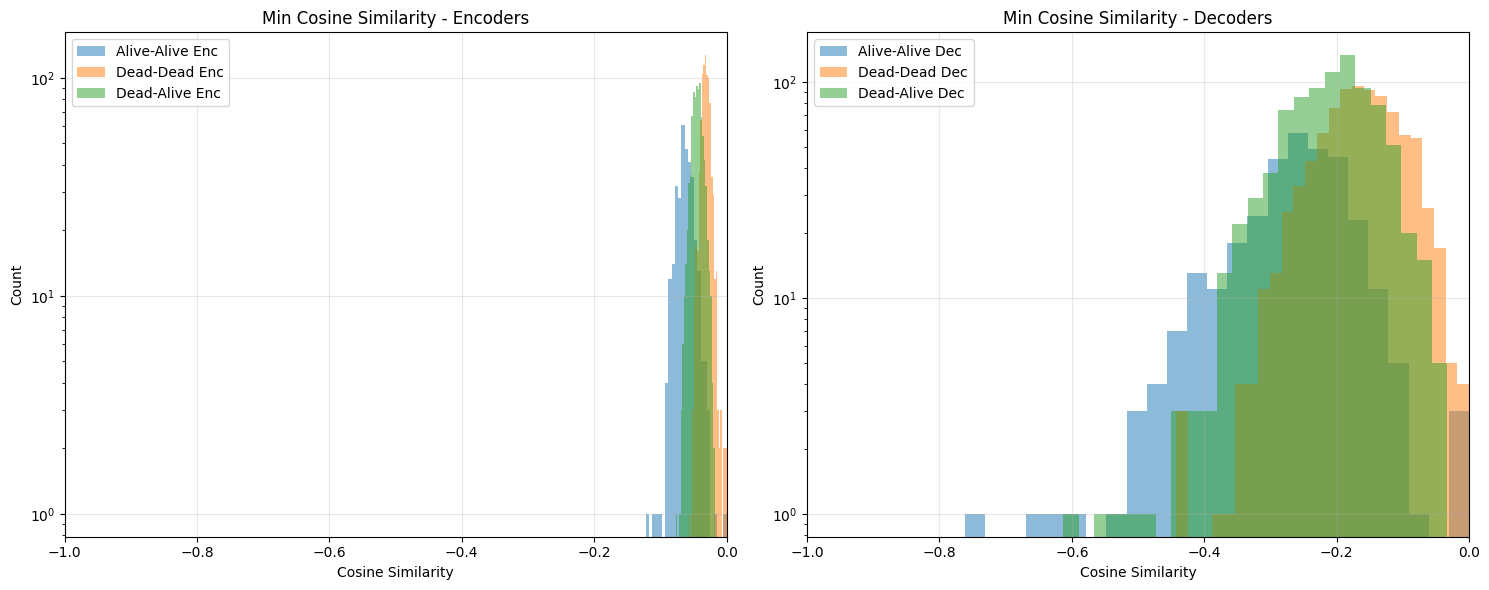

In [10]:
# Plot MMCS histograms
fig4 = plot_mmcs_histograms(
    mmcs_metrics=results.mmcs_metrics,
    plot_type='max'
)
fig4.show()

fig5 = plot_mmcs_histograms(
    mmcs_metrics=results.mmcs_metrics,
    plot_type='min'
)
fig5.show()


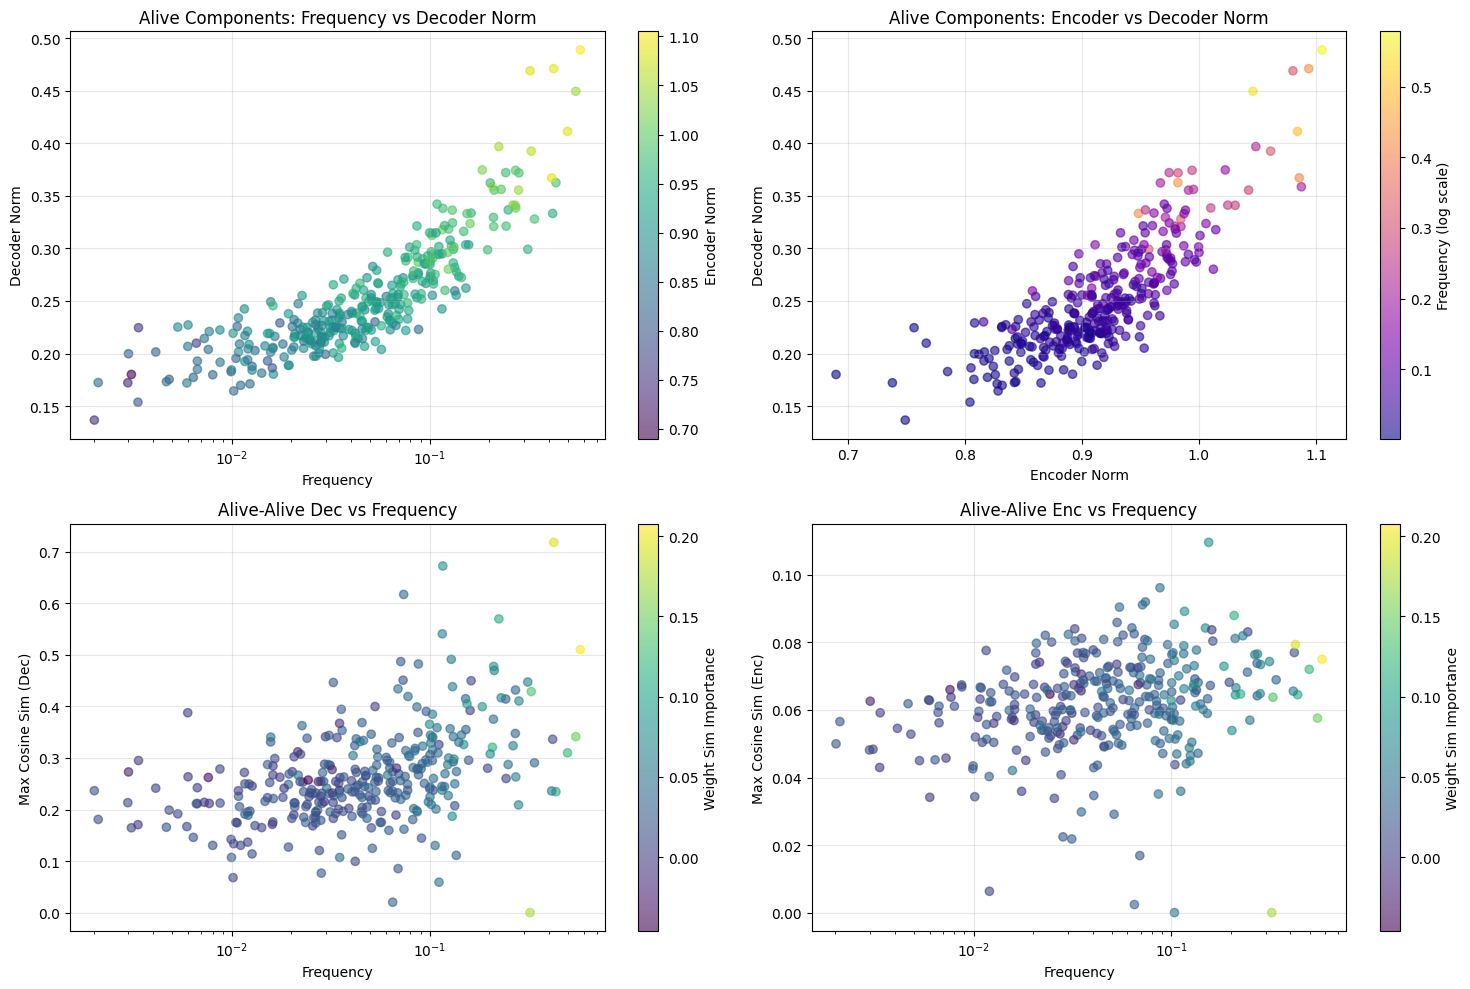

In [11]:
# Plot alive component relationships
alive_freq = results.frequency[results.alive_mask]
alive_enc_norms = results.enc_norms[results.alive_mask]
alive_dec_norms = results.dec_norms[results.alive_mask]
weight_sim_imp_alive = results.weight_sim_importance[results.alive_mask]

fig6 = plot_alive_frequency_relationships(
    alive_freq=alive_freq,
    alive_enc_norms=alive_enc_norms,
    alive_dec_norms=alive_dec_norms,
    mmcs_a_a_enc=results.mmcs_metrics['max']['mmcs_a_a_enc'],
    mmcs_a_a_dec=results.mmcs_metrics['max']['mmcs_a_a_dec'],
    weight_sim_imp_alive=weight_sim_imp_alive
)
fig6.show()


 ## Correlation Analysis

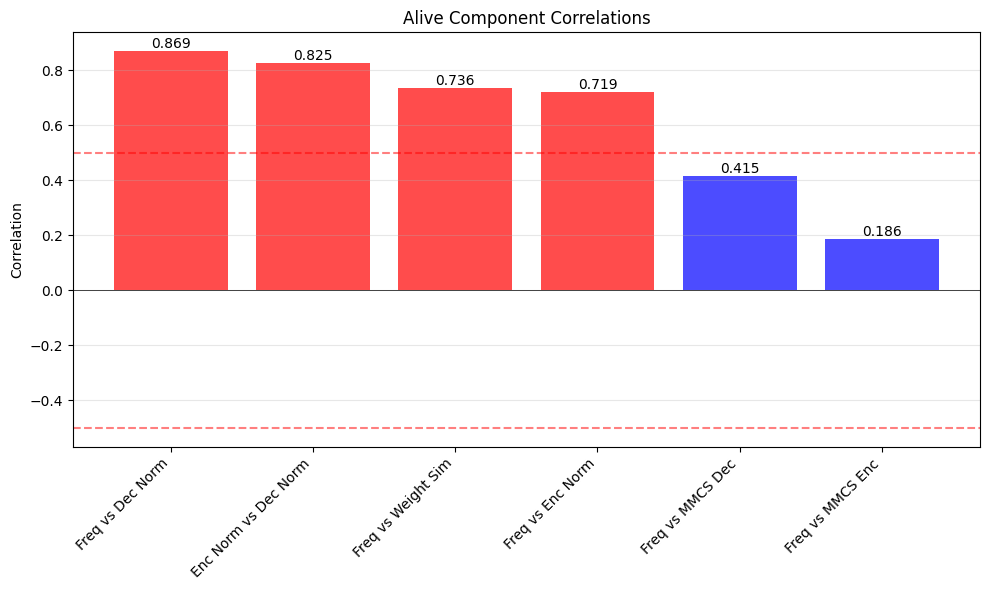

In [12]:
import numpy as np

# Calculate correlations for alive components
alive_correlations = {
    'Freq vs Enc Norm': np.corrcoef(alive_freq.cpu(), alive_enc_norms.cpu())[0, 1],
    'Freq vs Dec Norm': np.corrcoef(alive_freq.cpu(), alive_dec_norms.cpu())[0, 1],
    'Enc Norm vs Dec Norm': np.corrcoef(alive_enc_norms.cpu(), alive_dec_norms.cpu())[0, 1],
    'Freq vs Weight Sim': np.corrcoef(alive_freq.cpu(), weight_sim_imp_alive.cpu())[0, 1],
    'Freq vs MMCS Enc': np.corrcoef(
        alive_freq.cpu(), 
        results.mmcs_metrics['max']['mmcs_a_a_enc'].cpu()
    )[0, 1],
    'Freq vs MMCS Dec': np.corrcoef(
        alive_freq.cpu(), 
        results.mmcs_metrics['max']['mmcs_a_a_dec'].cpu()
    )[0, 1],
}

fig7 = plot_correlation_summary(
    correlations=alive_correlations,
    title="Alive Component Correlations",
    highlight_threshold=0.5
)
fig7.show()


In [13]:
# Print detailed statistics
print("Component Analysis Summary")
print("=" * 50)
print(f"Total components: {num_components}")
print(f"Alive components: {results.alive_mask.sum().item()} ({results.alive_mask.sum().item()/num_components*100:.1f}%)")
print(f"Dead components: {results.dead_mask.sum().item()} ({results.dead_mask.sum().item()/num_components*100:.1f}%)")
print(f"\nFrequency range: [{results.frequency.min():.6f}, {results.frequency.max():.6f}]")
print(f"Weight sim range: [{results.weight_sim_importance.min():.3f}, {results.weight_sim_importance.max():.3f}]")
print(f"\nEncoder norm range: [{results.enc_norms.min():.3f}, {results.enc_norms.max():.3f}]")
print(f"Decoder norm range: [{results.dec_norms.min():.3f}, {results.dec_norms.max():.3f}]")


Component Analysis Summary
Total components: 1200
Alive components: 324 (27.0%)
Dead components: 876 (73.0%)

Frequency range: [0.000000, 0.578102]
Weight sim range: [-0.046, 0.208]

Encoder norm range: [0.281, 1.105]
Decoder norm range: [0.030, 0.489]


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

def create_similarity_graph(similarity_matrix, threshold=0.6, matrix_type="AA", 
                          alive_dead_type="alive", node_labels=None, 
                          alive_norms=None, dead_norms=None,
                          figsize=(12, 10), seed=42):
    """
    Create a force-directed graph from a cosine similarity matrix.
    
    Parameters:
    -----------
    similarity_matrix : torch.Tensor or numpy.ndarray
        Cosine similarity matrix (can be rectangular for alive-dead comparisons)
    threshold : float
        Only show edges with |similarity| > threshold
    matrix_type : str
        "AA" or "BB" to indicate which type of components
    alive_dead_type : str
        "alive", "dead", "alive-dead", or "dead-alive"
    node_labels : list, optional
        Custom labels for nodes
    alive_norms : array-like, optional
        Norms for alive components
    dead_norms : array-like, optional
        Norms for dead components
    figsize : tuple
        Figure size
    seed : int
        Random seed for reproducible layout
    """
    
    # Convert to numpy if torch tensor
    if hasattr(similarity_matrix, 'cpu'):
        sim_matrix = similarity_matrix.cpu().numpy()
    else:
        sim_matrix = similarity_matrix
    
    # Convert norms to numpy if needed
    if alive_norms is not None and hasattr(alive_norms, 'cpu'):
        alive_norms = alive_norms.cpu().numpy()
    if dead_norms is not None and hasattr(dead_norms, 'cpu'):
        dead_norms = dead_norms.cpu().numpy()
    
    # Create graph
    G = nx.Graph()
    
    # First, find all edges that meet the threshold
    edges_to_add = []
    nodes_to_keep = set()
    
    if alive_dead_type in ["alive", "dead"]:
        # Square matrix case - only check lower triangle
        n_nodes = sim_matrix.shape[0]
        for i in range(n_nodes):
            for j in range(i):
                weight = sim_matrix[i, j]
                if abs(weight) > threshold:
                    edges_to_add.append((i, j, weight))
                    nodes_to_keep.add(i)
                    nodes_to_keep.add(j)
                    
    else:  # alive-dead or dead-alive
        # Rectangular matrix case
        n_rows, n_cols = sim_matrix.shape
        for i in range(n_rows):
            for j in range(n_cols):
                weight = sim_matrix[i, j]
                if abs(weight) > threshold:
                    edges_to_add.append((f"row_{i}", f"col_{j}", weight))
                    nodes_to_keep.add(f"row_{i}")
                    nodes_to_keep.add(f"col_{j}")
    
    # If no edges meet threshold, return empty graph
    if not edges_to_add:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, f"No connections found with threshold > {threshold}", 
                transform=ax.transAxes, ha='center', va='center', fontsize=16)
        ax.axis('off')
        return fig, G
    
    # Now add only the nodes that have edges
    if alive_dead_type in ["alive", "dead"]:
        # Square matrix case
        for i in nodes_to_keep:
            label = node_labels[i] if node_labels else f"{matrix_type}_{i}"
            G.add_node(i, label=label, type=alive_dead_type, component=matrix_type)
    else:
        # Rectangular matrix case
        if alive_dead_type == "alive-dead":
            row_type, col_type = "alive", "dead"
        else:
            row_type, col_type = "dead", "alive"
            
        for node in nodes_to_keep:
            if node.startswith("row_"):
                idx = int(node.split("_")[1])
                label = f"{matrix_type}_{row_type}_{idx}"
                G.add_node(node, label=label, type=row_type, component=matrix_type, index=idx)
            else:  # col_
                idx = int(node.split("_")[1])
                label = f"{matrix_type}_{col_type}_{idx}"
                G.add_node(node, label=label, type=col_type, component=matrix_type, index=idx)
    
    # Add edges
    for u, v, weight in edges_to_add:
        G.add_edge(u, v, weight=weight)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Calculate layout
    pos = nx.spring_layout(G, k=2/np.sqrt(len(G.nodes())), iterations=50, seed=seed)
    
    # Create node colors and sizes based on actual nodes in graph
    node_colors = []
    node_sizes = []
    
    for node in G.nodes():
        node_type = G.nodes[node]['type']
        component = G.nodes[node]['component']
        
        # Set colors
        if component == "AA":
            if node_type == "alive":
                node_colors.append('#2E7D32')  # Green for AA alive
            else:
                node_colors.append('#B71C1C')  # Dark red for AA dead
        else:  # BB
            if node_type == "alive":
                node_colors.append('#1976D2')  # Blue for BB alive
            else:
                node_colors.append('#F57C00')  # Orange for BB dead
        
        # Set sizes based on norms
        if alive_dead_type in ["alive", "dead"]:
            # Square matrix - use alive or dead norms based on type
            if node_type == "alive" and alive_norms is not None:
                node_sizes.append(alive_norms[node])
            elif node_type == "dead" and dead_norms is not None:
                node_sizes.append(dead_norms[node])
            else:
                node_sizes.append(1.0)  # default if no norms provided
        else:
            # Rectangular matrix - use index stored in node
            idx = G.nodes[node]['index']
            if node_type == "alive" and alive_norms is not None:
                node_sizes.append(alive_norms[idx])
            elif node_type == "dead" and dead_norms is not None:
                node_sizes.append(dead_norms[idx])
            else:
                node_sizes.append(1.0)  # default if no norms provided
    
    # Scale node sizes (adjust multiplier as needed)
    if any(norms is not None for norms in [alive_norms, dead_norms]):
        node_sizes = [max(50, size * 100) for size in node_sizes]  # min size 50, scale by 100
    else:
        node_sizes = 300  # default size when no norms provided
    
    # Separate positive and negative edges
    pos_edges = [(u, v) for u, v, w in G.edges(data='weight') if w > 0]
    neg_edges = [(u, v) for u, v, w in G.edges(data='weight') if w < 0]
    
    # Draw positive edges in blue
    if pos_edges:
        pos_weights = [G[u][v]['weight'] for u, v in pos_edges]
        nx.draw_networkx_edges(G, pos, pos_edges, 
                              width=[w*4 for w in pos_weights],
                              alpha=[min((w - threshold) / (1 - threshold), 1) for w in pos_weights],
                              edge_color='blue', ax=ax)
    
    # Draw negative edges in red
    if neg_edges:
        neg_weights = [abs(G[u][v]['weight']) for u, v in neg_edges]
        nx.draw_networkx_edges(G, pos, neg_edges,
                              width=[w*4 for w in neg_weights],
                              alpha=[min((w - threshold) / (1 - threshold), 1) for w in neg_weights],
                              edge_color='red', ax=ax)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=0.8, ax=ax)
    
    # Draw labels
    labels = {node: G.nodes[node]['label'] for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=8, ax=ax)
    
    # Add title and legend
    title = f"{matrix_type} Cosine Similarity Network ({alive_dead_type})"
    ax.set_title(title, fontsize=16, fontweight='bold')
    
    # Create legend
    legend_elements = []
    
    # Only add legend items for node types that actually exist in the graph
    node_types_in_graph = set((G.nodes[node]['component'], G.nodes[node]['type']) for node in G.nodes())
    
    if ('AA', 'alive') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#2E7D32', label='AA Alive'))
    if ('AA', 'dead') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#B71C1C', label='AA Dead'))
    if ('BB', 'alive') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#1976D2', label='BB Alive'))
    if ('BB', 'dead') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#F57C00', label='BB Dead'))
    
    if pos_edges:
        legend_elements.append(mpatches.Patch(color='blue', label='Positive Similarity'))
    if neg_edges:
        legend_elements.append(mpatches.Patch(color='red', label='Negative Similarity'))
    
    if any(norms is not None for norms in [alive_norms, dead_norms]):
        legend_elements.append(mpatches.Patch(color='gray', label='Node size = vector norm'))
    
    ax.legend(handles=legend_elements, loc='upper right')
    
    # Add statistics
    stats_text = f"Nodes: {len(G.nodes())}\nEdges: {len(G.edges())}\nThreshold: {threshold}"
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5),
            verticalalignment='bottom')
    
    ax.axis('off')
    plt.tight_layout()
    
    return fig, G


def plot_all_similarity_graphs(aa_cos_sim_alive, bb_cos_sim_alive, 
                              aa_cos_sim_alive_dead=None, bb_cos_sim_alive_dead=None,
                              aa_cos_sim_dead=None, bb_cos_sim_dead=None,
                              A_alive_norms=None, A_dead_norms=None,
                              B_alive_norms=None, B_dead_norms=None,
                              threshold=0.6, save_path=None):
    """
    Plot all cosine similarity graphs for different component combinations.
    
    Parameters:
    -----------
    aa_cos_sim_alive : torch.Tensor
        AA cosine similarities for alive components (lower triangular)
    bb_cos_sim_alive : torch.Tensor
        BB cosine similarities for alive components (lower triangular)
    aa_cos_sim_alive_dead : torch.Tensor, optional
        AA cosine similarities between alive and dead components
    bb_cos_sim_alive_dead : torch.Tensor, optional
        BB cosine similarities between alive and dead components
    aa_cos_sim_dead : torch.Tensor, optional
        AA cosine similarities for dead components (lower triangular)
    bb_cos_sim_dead : torch.Tensor, optional
        BB cosine similarities for dead components (lower triangular)
    A_alive_norms : array-like, optional
        Norms for alive A components
    A_dead_norms : array-like, optional
        Norms for dead A components
    B_alive_norms : array-like, optional
        Norms for alive B components
    B_dead_norms : array-like, optional
        Norms for dead B components
    threshold : float
        Similarity threshold for displaying edges
    save_path : str, optional
        Path to save the figures
    """
    
    figures = []
    
    # Plot AA alive
    fig1, G1 = create_similarity_graph(aa_cos_sim_alive, threshold=threshold, 
                                      matrix_type="AA", alive_dead_type="alive",
                                      alive_norms=A_alive_norms)
    figures.append(('AA_alive', fig1))
    
    # Plot BB alive
    fig2, G2 = create_similarity_graph(bb_cos_sim_alive, threshold=threshold,
                                      matrix_type="BB", alive_dead_type="alive",
                                      alive_norms=B_alive_norms)
    figures.append(('BB_alive', fig2))
    
    # Plot alive-dead connections if provided
    if aa_cos_sim_alive_dead is not None:
        fig3, G3 = create_similarity_graph(aa_cos_sim_alive_dead, threshold=threshold,
                                          matrix_type="AA", alive_dead_type="alive-dead",
                                          alive_norms=A_alive_norms, dead_norms=A_dead_norms)
        figures.append(('AA_alive_dead', fig3))
    
    if bb_cos_sim_alive_dead is not None:
        fig4, G4 = create_similarity_graph(bb_cos_sim_alive_dead, threshold=threshold,
                                          matrix_type="BB", alive_dead_type="alive-dead",
                                          alive_norms=B_alive_norms, dead_norms=B_dead_norms)
        figures.append(('BB_alive_dead', fig4))
    
    # Plot dead-dead connections if provided
    if aa_cos_sim_dead is not None:
        fig5, G5 = create_similarity_graph(aa_cos_sim_dead, threshold=threshold,
                                          matrix_type="AA", alive_dead_type="dead",
                                          dead_norms=A_dead_norms)
        figures.append(('AA_dead', fig5))
    
    if bb_cos_sim_dead is not None:
        fig6, G6 = create_similarity_graph(bb_cos_sim_dead, threshold=threshold,
                                          matrix_type="BB", alive_dead_type="dead",
                                          dead_norms=B_dead_norms)
        figures.append(('BB_dead', fig6))
    
    # Save figures if path provided
    if save_path:
        for name, fig in figures:
            fig.savefig(f"{save_path}_{name}.png", dpi=300, bbox_inches='tight')
    
    return figures


# Example usage with norms:
# Calculate norms BEFORE normalizing
# A_alive_norms = A_alive.norm(dim=0).cpu().numpy()
# B_alive_norms = B_alive.norm(dim=1).cpu().numpy()
# A_dead_norms = A_dead.norm(dim=0).cpu().numpy()
# B_dead_norms = B_dead.norm(dim=1).cpu().numpy()

# Plot with norms
# figures = plot_all_similarity_graphs(
#     aa_cos_sim_alive=aa_cos_sim_alive,
#     bb_cos_sim_alive=bb_cos_sim_alive,
#     aa_cos_sim_alive_dead=aa_cos_sim_alive_dead,
#     bb_cos_sim_alive_dead=bb_cos_sim_alive_dead,
#     aa_cos_sim_dead=aa_cos_sim_dead,
#     bb_cos_sim_dead=bb_cos_sim_dead,
#     A_alive_norms=A_alive_norms,
#     A_dead_norms=A_dead_norms,
#     B_alive_norms=B_alive_norms,
#     B_dead_norms=B_dead_norms,
#     threshold=0.6,
#     save_path="similarity_graphs_with_norms"
# )

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

def create_similarity_graph(similarity_matrix, threshold=0.6, matrix_type="AA", 
                          alive_dead_type="alive", node_labels=None, 
                          alive_norms=None, dead_norms=None,
                          figsize=(12, 10), seed=42):
    """
    Create a force-directed graph from a cosine similarity matrix.
    
    Parameters:
    -----------
    similarity_matrix : torch.Tensor or numpy.ndarray
        Cosine similarity matrix (can be rectangular for alive-dead comparisons)
    threshold : float
        Only show edges with |similarity| > threshold
    matrix_type : str
        "AA" or "BB" to indicate which type of components
    alive_dead_type : str
        "alive", "dead", "alive-dead", or "dead-alive"
    node_labels : list, optional
        Custom labels for nodes
    alive_norms : array-like, optional
        Norms for alive components
    dead_norms : array-like, optional
        Norms for dead components
    figsize : tuple
        Figure size
    seed : int
        Random seed for reproducible layout
    """
    
    # Convert to numpy if torch tensor
    if hasattr(similarity_matrix, 'cpu'):
        sim_matrix = similarity_matrix.cpu().numpy()
    else:
        sim_matrix = similarity_matrix
    
    # Convert norms to numpy if needed
    if alive_norms is not None and hasattr(alive_norms, 'cpu'):
        alive_norms = alive_norms.cpu().numpy()
    if dead_norms is not None and hasattr(dead_norms, 'cpu'):
        dead_norms = dead_norms.cpu().numpy()
    
    # Create graph
    G = nx.Graph()
    
    # First, find all edges that meet the threshold
    edges_to_add = []
    nodes_to_keep = set()
    
    if alive_dead_type in ["alive", "dead"]:
        # Square matrix case - only check lower triangle
        n_nodes = sim_matrix.shape[0]
        for i in range(n_nodes):
            for j in range(i):
                weight = sim_matrix[i, j]
                if abs(weight) > threshold:
                    edges_to_add.append((i, j, weight))
                    nodes_to_keep.add(i)
                    nodes_to_keep.add(j)
                    
    else:  # alive-dead or dead-alive
        # Rectangular matrix case
        n_rows, n_cols = sim_matrix.shape
        for i in range(n_rows):
            for j in range(n_cols):
                weight = sim_matrix[i, j]
                if abs(weight) > threshold:
                    edges_to_add.append((f"row_{i}", f"col_{j}", weight))
                    nodes_to_keep.add(f"row_{i}")
                    nodes_to_keep.add(f"col_{j}")
    
    # If no edges meet threshold, return empty graph
    if not edges_to_add:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, f"No connections found with threshold > {threshold}", 
                transform=ax.transAxes, ha='center', va='center', fontsize=16)
        ax.axis('off')
        return fig, G
    
    # Now add only the nodes that have edges
    if alive_dead_type in ["alive", "dead"]:
        # Square matrix case
        for i in nodes_to_keep:
            label = node_labels[i] if node_labels else f"{matrix_type}_{i}"
            G.add_node(i, label=label, type=alive_dead_type, component=matrix_type)
    else:
        # Rectangular matrix case
        if alive_dead_type == "alive-dead":
            row_type, col_type = "alive", "dead"
        else:
            row_type, col_type = "dead", "alive"
            
        for node in nodes_to_keep:
            if node.startswith("row_"):
                idx = int(node.split("_")[1])
                label = f"{matrix_type}_{row_type}_{idx}"
                G.add_node(node, label=label, type=row_type, component=matrix_type, index=idx)
            else:  # col_
                idx = int(node.split("_")[1])
                label = f"{matrix_type}_{col_type}_{idx}"
                G.add_node(node, label=label, type=col_type, component=matrix_type, index=idx)
    
    # Add edges
    for u, v, weight in edges_to_add:
        G.add_edge(u, v, weight=weight)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Calculate layout
    pos = nx.spring_layout(G, k=2/np.sqrt(len(G.nodes())), iterations=50, seed=seed)
    
    # Create node colors and sizes based on actual nodes in graph
    node_colors = []
    node_sizes = []
    
    for node in G.nodes():
        node_type = G.nodes[node]['type']
        component = G.nodes[node]['component']
        
        # Set colors
        if component == "AA":
            if node_type == "alive":
                node_colors.append('#2E7D32')  # Green for AA alive
            else:
                node_colors.append('#B71C1C')  # Dark red for AA dead
        else:  # BB
            if node_type == "alive":
                node_colors.append('#1976D2')  # Blue for BB alive
            else:
                node_colors.append('#F57C00')  # Orange for BB dead
        
        # Set sizes based on norms
        if alive_dead_type in ["alive", "dead"]:
            # Square matrix - use alive or dead norms based on type
            if node_type == "alive" and alive_norms is not None:
                node_sizes.append(alive_norms[node])
            elif node_type == "dead" and dead_norms is not None:
                node_sizes.append(dead_norms[node])
            else:
                node_sizes.append(1.0)  # default if no norms provided
        else:
            # Rectangular matrix - use index stored in node
            idx = G.nodes[node]['index']
            if node_type == "alive" and alive_norms is not None:
                node_sizes.append(alive_norms[idx])
            elif node_type == "dead" and dead_norms is not None:
                node_sizes.append(dead_norms[idx])
            else:
                node_sizes.append(1.0)  # default if no norms provided
    
    # Scale node sizes (adjust multiplier as needed)
    if any(norms is not None for norms in [alive_norms, dead_norms]):
        node_sizes = [max(50, size * 100) for size in node_sizes]  # min size 50, scale by 100
    else:
        node_sizes = 300  # default size when no norms provided
    
    # Separate positive and negative edges
    pos_edges = [(u, v) for u, v, w in G.edges(data='weight') if w > 0]
    neg_edges = [(u, v) for u, v, w in G.edges(data='weight') if w < 0]
    
    # Draw positive edges in blue
    if pos_edges:
        pos_weights = [G[u][v]['weight'] for u, v in pos_edges]
        nx.draw_networkx_edges(G, pos, pos_edges, 
                              width=[w*4 for w in pos_weights],
                              alpha=[min((w - threshold) / (1 - threshold), 1) for w in pos_weights],
                              edge_color='blue', ax=ax)
    
    # Draw negative edges in red
    if neg_edges:
        neg_weights = [abs(G[u][v]['weight']) for u, v in neg_edges]
        nx.draw_networkx_edges(G, pos, neg_edges,
                              width=[w*4 for w in neg_weights],
                              alpha=[min((w - threshold) / (1 - threshold), 1) for w in neg_weights],
                              edge_color='red', ax=ax)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=0.8, ax=ax)
    
    # Draw labels
    labels = {node: G.nodes[node]['label'] for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=8, ax=ax)
    
    # Add title and legend
    title = f"{matrix_type} Cosine Similarity Network ({alive_dead_type})"
    ax.set_title(title, fontsize=16, fontweight='bold')
    
    # Create legend
    legend_elements = []
    
    # Only add legend items for node types that actually exist in the graph
    node_types_in_graph = set((G.nodes[node]['component'], G.nodes[node]['type']) for node in G.nodes())
    
    if ('AA', 'alive') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#2E7D32', label='AA Alive'))
    if ('AA', 'dead') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#B71C1C', label='AA Dead'))
    if ('BB', 'alive') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#1976D2', label='BB Alive'))
    if ('BB', 'dead') in node_types_in_graph:
        legend_elements.append(mpatches.Patch(color='#F57C00', label='BB Dead'))
    
    if pos_edges:
        legend_elements.append(mpatches.Patch(color='blue', label='Positive Similarity'))
    if neg_edges:
        legend_elements.append(mpatches.Patch(color='red', label='Negative Similarity'))
    
    if any(norms is not None for norms in [alive_norms, dead_norms]):
        legend_elements.append(mpatches.Patch(color='gray', label='Node size = vector norm'))
    
    ax.legend(handles=legend_elements, loc='upper right')
    
    # Add statistics
    stats_text = f"Nodes: {len(G.nodes())}\nEdges: {len(G.edges())}\nThreshold: {threshold}"
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, 
            bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5),
            verticalalignment='bottom')
    
    ax.axis('off')
    plt.tight_layout()
    
    return fig, G


def plot_all_similarity_graphs(aa_cos_sim_alive, bb_cos_sim_alive, 
                              aa_cos_sim_alive_dead=None, bb_cos_sim_alive_dead=None,
                              aa_cos_sim_dead=None, bb_cos_sim_dead=None,
                              A_alive_norms=None, A_dead_norms=None,
                              B_alive_norms=None, B_dead_norms=None,
                              threshold=0.6, save_path=None):
    """
    Plot all cosine similarity graphs for different component combinations.
    
    Parameters:
    -----------
    aa_cos_sim_alive : torch.Tensor
        AA cosine similarities for alive components (lower triangular)
    bb_cos_sim_alive : torch.Tensor
        BB cosine similarities for alive components (lower triangular)
    aa_cos_sim_alive_dead : torch.Tensor, optional
        AA cosine similarities between alive and dead components
    bb_cos_sim_alive_dead : torch.Tensor, optional
        BB cosine similarities between alive and dead components
    aa_cos_sim_dead : torch.Tensor, optional
        AA cosine similarities for dead components (lower triangular)
    bb_cos_sim_dead : torch.Tensor, optional
        BB cosine similarities for dead components (lower triangular)
    A_alive_norms : array-like, optional
        Norms for alive A components
    A_dead_norms : array-like, optional
        Norms for dead A components
    B_alive_norms : array-like, optional
        Norms for alive B components
    B_dead_norms : array-like, optional
        Norms for dead B components
    threshold : float
        Similarity threshold for displaying edges
    save_path : str, optional
        Path to save the figures
    """
    
    figures = []
    
    # Plot AA alive
    fig1, G1 = create_similarity_graph(aa_cos_sim_alive, threshold=threshold, 
                                      matrix_type="AA", alive_dead_type="alive",
                                      alive_norms=A_alive_norms)
    figures.append(('AA_alive', fig1))
    
    # Plot BB alive
    fig2, G2 = create_similarity_graph(bb_cos_sim_alive, threshold=threshold,
                                      matrix_type="BB", alive_dead_type="alive",
                                      alive_norms=B_alive_norms)
    figures.append(('BB_alive', fig2))
    
    # Plot alive-dead connections if provided
    if aa_cos_sim_alive_dead is not None:
        fig3, G3 = create_similarity_graph(aa_cos_sim_alive_dead, threshold=threshold,
                                          matrix_type="AA", alive_dead_type="alive-dead",
                                          alive_norms=A_alive_norms, dead_norms=A_dead_norms)
        figures.append(('AA_alive_dead', fig3))
    
    if bb_cos_sim_alive_dead is not None:
        fig4, G4 = create_similarity_graph(bb_cos_sim_alive_dead, threshold=threshold,
                                          matrix_type="BB", alive_dead_type="alive-dead",
                                          alive_norms=B_alive_norms, dead_norms=B_dead_norms)
        figures.append(('BB_alive_dead', fig4))
    
    # Plot dead-dead connections if provided
    if aa_cos_sim_dead is not None:
        fig5, G5 = create_similarity_graph(aa_cos_sim_dead, threshold=threshold,
                                          matrix_type="AA", alive_dead_type="dead",
                                          dead_norms=A_dead_norms)
        figures.append(('AA_dead', fig5))
    
    if bb_cos_sim_dead is not None:
        fig6, G6 = create_similarity_graph(bb_cos_sim_dead, threshold=threshold,
                                          matrix_type="BB", alive_dead_type="dead",
                                          dead_norms=B_dead_norms)
        figures.append(('BB_dead', fig6))
    
    # Save figures if path provided
    if save_path:
        for name, fig in figures:
            fig.savefig(f"{save_path}_{name}.png", dpi=300, bbox_inches='tight')
    
    return figures


tensor([0.0000, 0.0000, 0.0030,  ..., 0.0000, 0.3219, 0.0000])

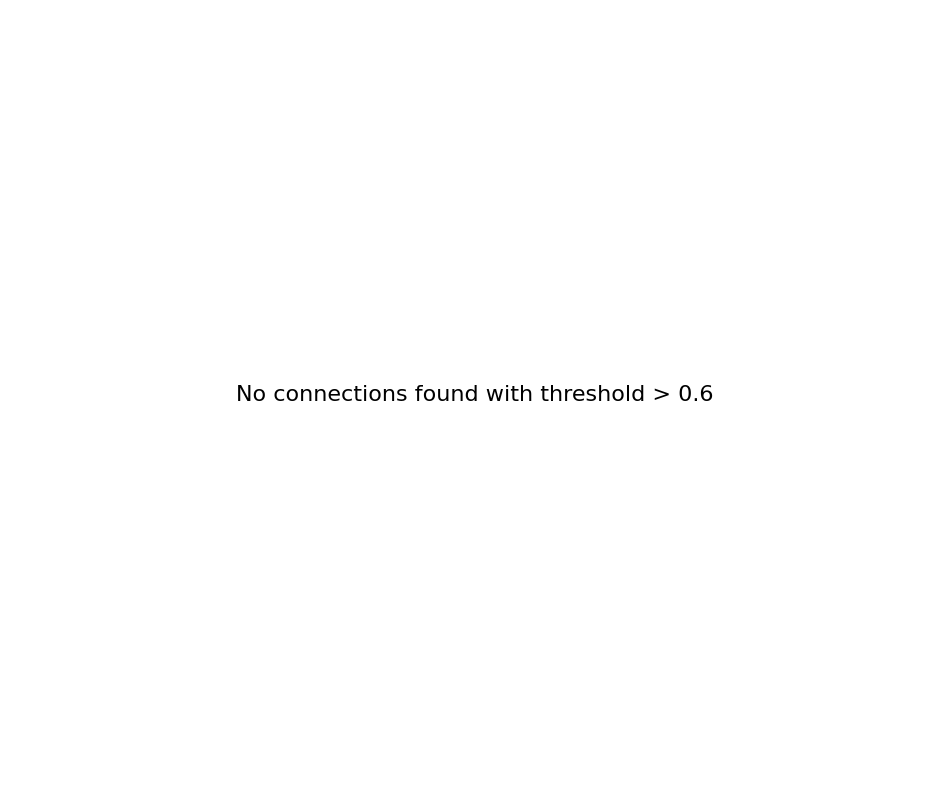

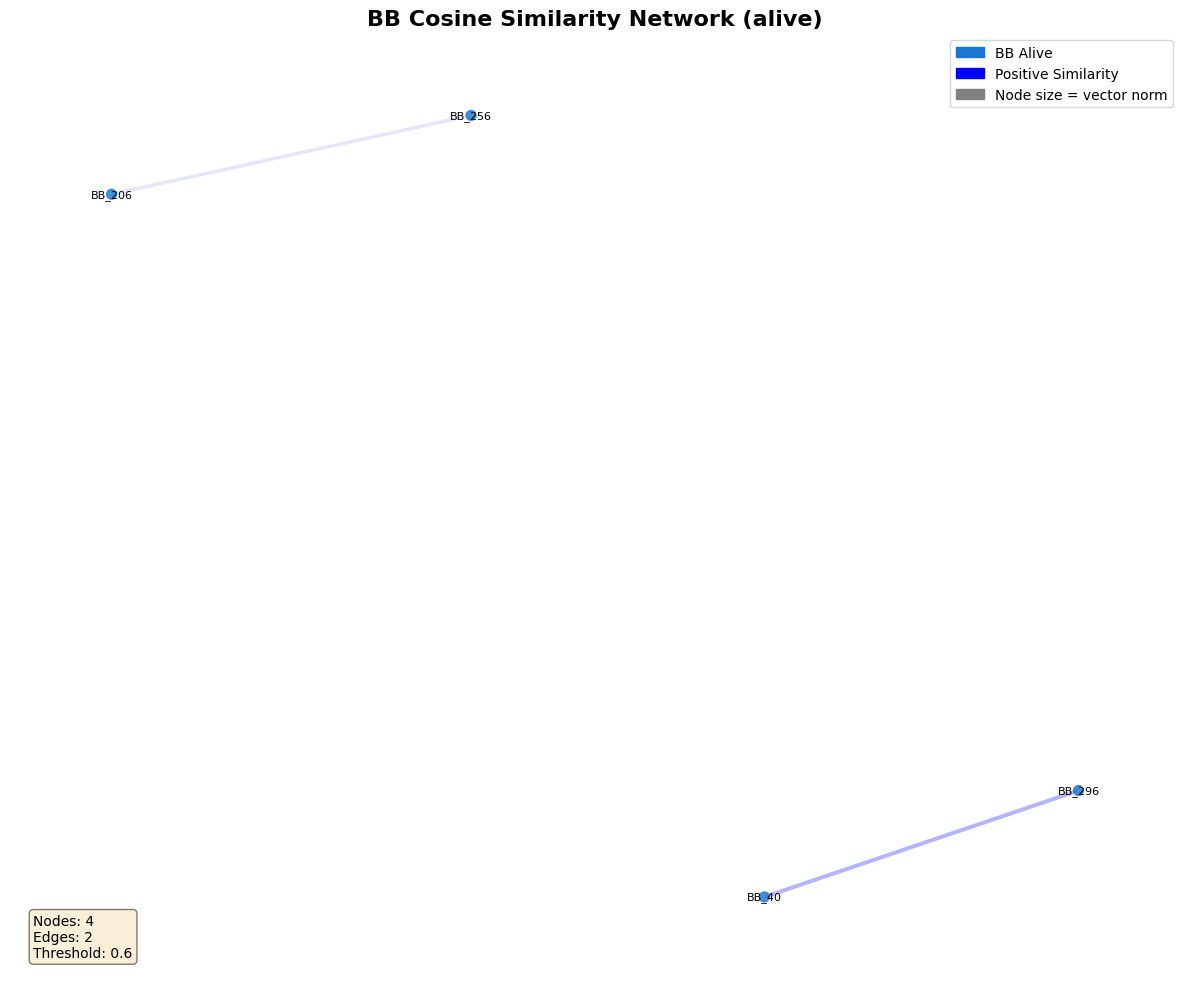

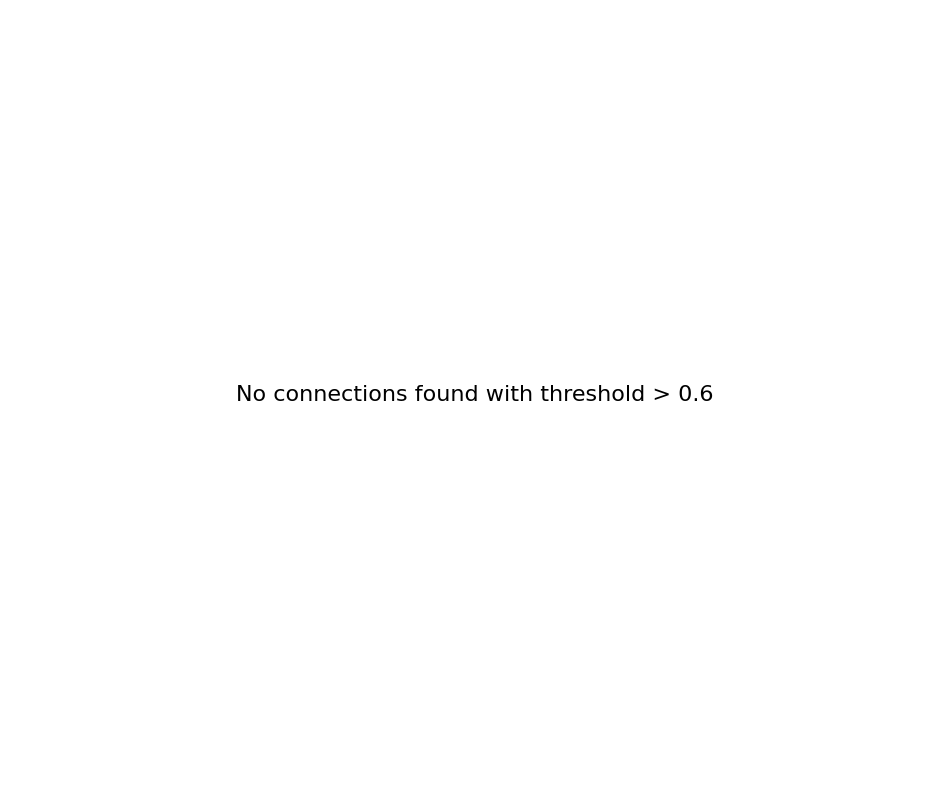

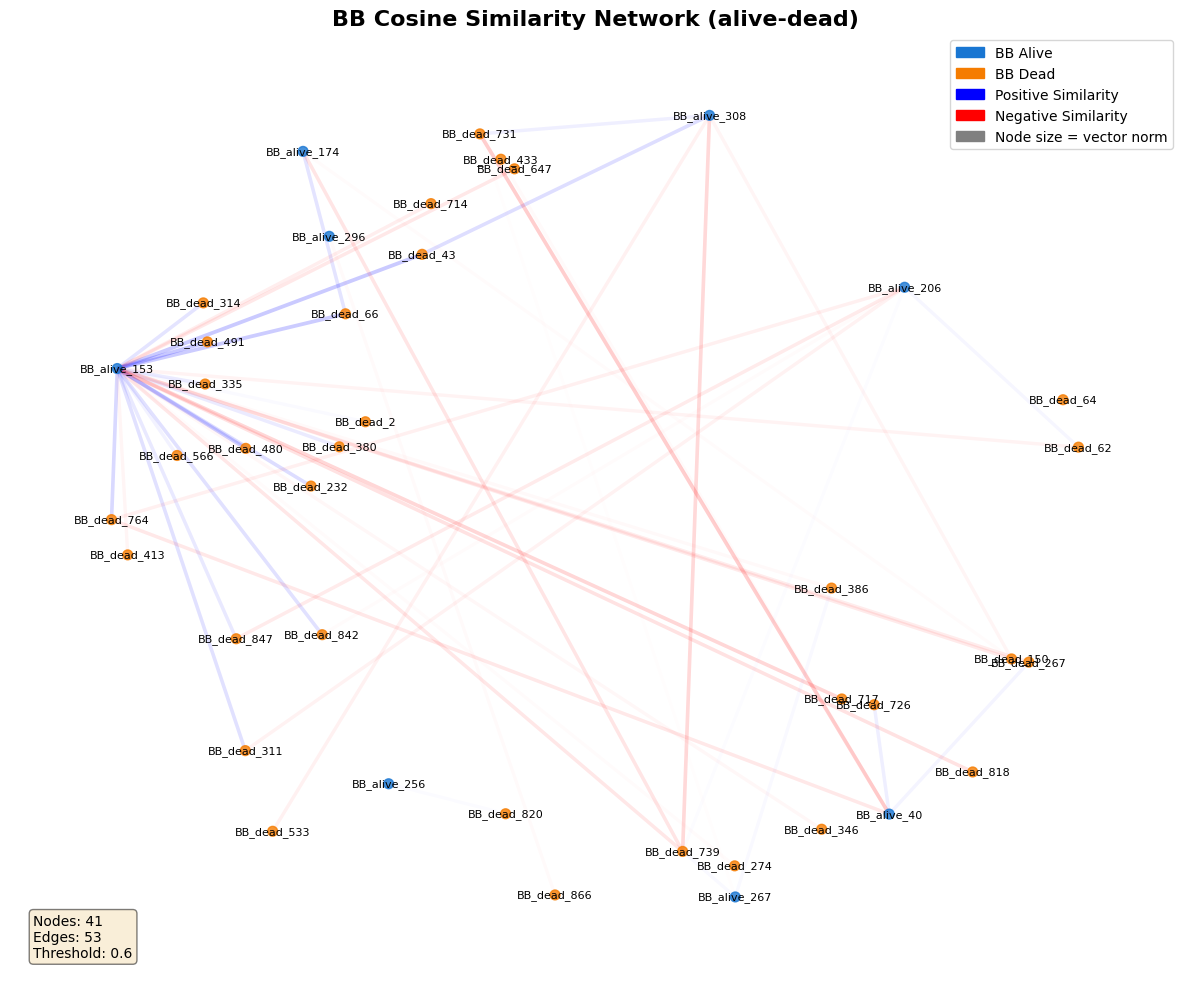

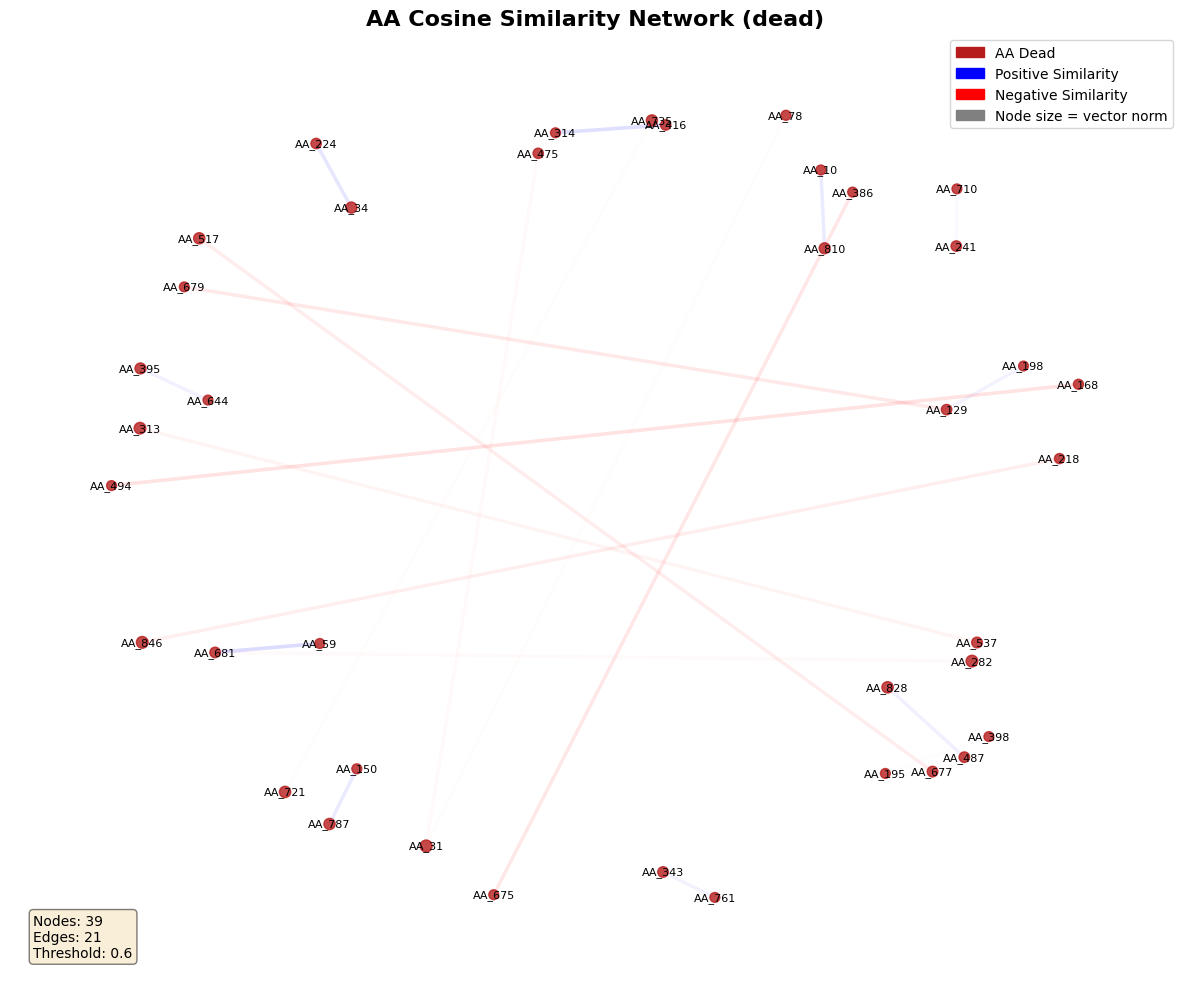

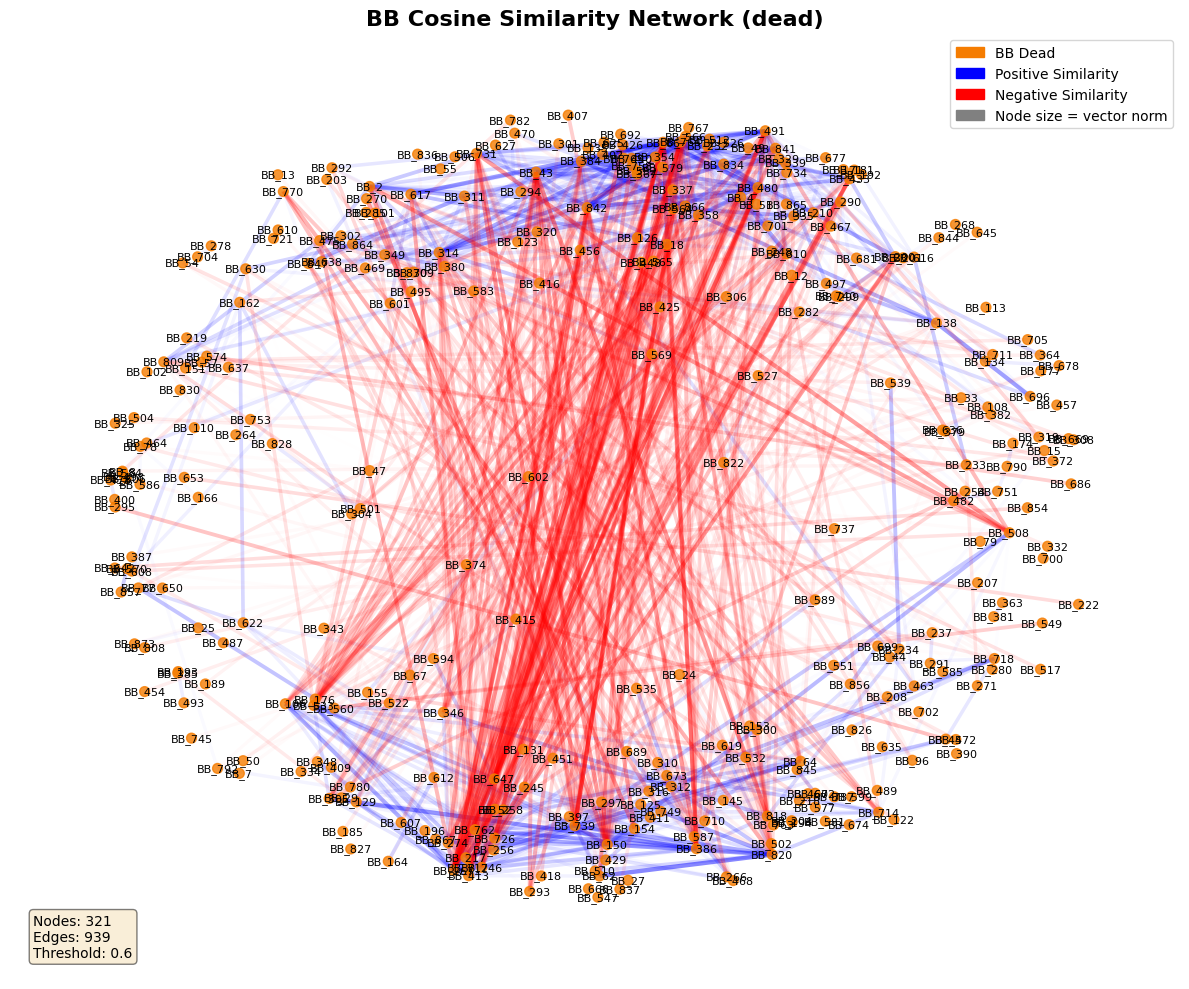

In [ ]:
alive_mask = (results.frequency > 0)
dead_mask = (results.frequency == 0)

layer_name = module_name

# Split components into alive and dead
A_alive = components[layer_name].A[:, alive_mask]
B_alive = components[layer_name].B[alive_mask, :]
A_dead = components[layer_name].A[:, dead_mask]
B_dead = components[layer_name].B[dead_mask, :]

alive_frequencies = results.frequency[alive_mask].cpu().numpy()

# Normalize alive components
normed_A_alive = torch.nn.functional.normalize(A_alive, dim=0)  # [d_model, n_components_alive]
normed_B_alive = torch.nn.functional.normalize(B_alive, dim=1)  # [n_components_alive, d_out]

# Normalize dead components (if any exist)
normed_A_dead = torch.nn.functional.normalize(A_dead, dim=0)  # [d_model, n_components_dead]
normed_B_dead = torch.nn.functional.normalize(B_dead, dim=1)  # [n_components_dead, d_out]

# Compute cosine similarities for alive components
aa_cos_sim_alive = (normed_A_alive.T @ normed_A_alive).tril(diagonal=-1)
bb_cos_sim_alive = (normed_B_alive @ normed_B_alive.T).tril(diagonal=-1)

# Compute cosine similarities between alive and dead A components
aa_cos_sim_alive_dead = normed_A_alive.T @ normed_A_dead  # [n_alive, n_dead]
# mpute cosine similarities between alive and dead B components
bb_cos_sim_alive_dead = normed_B_alive @ normed_B_dead.T  # [n_alive, n_dead]

# Compute cosine similarities for dead components among themselves
aa_cos_sim_dead = (normed_A_dead.T @ normed_A_dead).tril(diagonal=-1)
bb_cos_sim_dead = (normed_B_dead @ normed_B_dead.T).tril(diagonal=-1)

A_alive_norms = A_alive.norm(dim=0).cpu().numpy()
B_alive_norms = B_alive.norm(dim=1).cpu().numpy()
A_dead_norms = A_dead.norm(dim=0).cpu().numpy()
B_dead_norms = B_dead.norm(dim=1).cpu().numpy()

# Plot with norms
figures = plot_all_similarity_graphs(
    aa_cos_sim_alive=aa_cos_sim_alive,
    bb_cos_sim_alive=bb_cos_sim_alive,
    aa_cos_sim_alive_dead=aa_cos_sim_alive_dead,
    bb_cos_sim_alive_dead=bb_cos_sim_alive_dead,
    aa_cos_sim_dead=aa_cos_sim_dead,
    bb_cos_sim_dead=bb_cos_sim_dead,
    A_alive_norms=A_alive_norms,
    A_dead_norms=A_dead_norms,
    B_alive_norms=B_alive_norms,
    B_dead_norms=B_dead_norms,
    threshold=0.5,
    save_path="similarity_graphs_with_norms"
)

In [39]:
bb_cos_sim_alive.max(dim=0).values.topk(k=10), bb_cos_sim_alive.min(dim=0).values.topk(k=10, largest=False)

(torch.return_types.topk(
 values=tensor([0.7178, 0.6409, 0.5607, 0.5481, 0.5278, 0.5076, 0.5050, 0.5014, 0.5014,
         0.4958], device='cuda:0'),
 indices=tensor([ 40, 206, 153, 110,  17, 187, 180,  65,  31,  60], device='cuda:0')),
 torch.return_types.topk(
 values=tensor([-0.5907, -0.5647, -0.5377, -0.5344, -0.5105, -0.5083, -0.5068, -0.5028,
         -0.5014, -0.5000], device='cuda:0'),
 indices=tensor([153, 211, 192, 187, 219, 174,  40, 267, 244,   8], device='cuda:0')))

In [22]:

import torch
import numpy as np
from tqdm import tqdm
from typing import Dict, Tuple, List
import matplotlib.pyplot as plt


# ==================== ANALYSIS FUNCTIONS ====================

def identify_low_frequency_components(
    frequency: torch.Tensor,
    min_threshold: float = 0.0,
    max_threshold: float = 0.001
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Identify low-frequency components within specified thresholds.
    
    Args:
        frequency: Component activation frequencies
        min_threshold: Minimum frequency (exclude dead components)
        max_threshold: Maximum frequency for "low-frequency" classification
        
    Returns:
        low_freq_mask: Boolean mask for low-frequency components
        low_freq_indices: Indices of low-frequency components
    """
    low_freq_mask = (frequency > min_threshold) & (frequency < max_threshold)
    low_freq_indices = torch.where(low_freq_mask)[0]
    
    return low_freq_mask, low_freq_indices


def calculate_kl_differences_for_low_freq_components(
    model,
    eval_loader,
    components,
    As,
    gates,
    module_comp,
    module_name,
    low_freq_indices: torch.Tensor,
    max_samples_per_component: int = 100,
    device: str = 'cuda'
) -> Dict[int, list]:
    """
    Calculate KL divergence differences when low-frequency components are ablated.
    
    For each low-frequency component, finds positions where it activates and
    calculates the KL divergence difference when the component is turned off.
    
    Args:
        model: The component model
        eval_loader: DataLoader for evaluation
        components: Component dictionary
        As: A matrices dictionary
        gates: Gates dictionary
        module_comp: Module component names for hooks
        module_name: Target module name
        low_freq_indices: Indices of low-frequency components to analyze
        max_samples_per_component: Maximum samples to collect per component
        device: Device to run on
        
    Returns:
        kl_differences: Dict mapping component index to list of KL differences
    """
    from spd.models.component_utils import calc_causal_importances
    from spd.utils import calc_kl_divergence_lm
    
    # Initialize storage
    kl_differences = {idx.item(): [] for idx in low_freq_indices}
    samples_collected = {idx.item(): 0 for idx in low_freq_indices}
    
    eval_iter = iter(eval_loader)
    total_batches_processed = 0
    
    # Process batches until we have enough samples for all components
    with torch.no_grad():
        for batch in tqdm(eval_iter, desc="Calculating KL differences"):
            # Check if we've collected enough samples for all components
            if all(count >= max_samples_per_component for count in samples_collected.values()):
                break
                
            batch_input = batch["input_ids"].to(device)
            batch_size, seq_len = batch_input.shape
            
            # Get original model output and activations
            orig_logits, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
                batch_input,
                module_names=module_comp
            )
            
            # Calculate causal importances
            causal_importances, _ = calc_causal_importances(
                pre_weight_acts=pre_weight_acts,
                As=As,
                gates=gates,
                detach_inputs=False
            )
            
            # Get baseline mask (clamped causal importances)
            baseline_mask = {k: v.clamp(0, 1) for k, v in causal_importances.items()}
            
            # Calculate baseline KL divergence
            baseline_logits = model.forward_with_components(
                batch_input,
                components=components,
                masks=baseline_mask
            )
            
            # For each low-frequency component
            for comp_idx in low_freq_indices:
                comp_idx_int = comp_idx.item()
                
                # Skip if we've collected enough samples
                if samples_collected[comp_idx_int] >= max_samples_per_component:
                    continue
                
                # Find positions where this component activates
                component_activations = causal_importances[module_name][:, :, comp_idx]
                active_positions = torch.where(component_activations > 0)
                
                if len(active_positions[0]) == 0:
                    continue
                
                # Process each activation position
                for batch_idx, seq_idx in zip(active_positions[0], active_positions[1]):
                    if samples_collected[comp_idx_int] >= max_samples_per_component:
                        break
                    
                    # Create mask with this component turned off
                    ablated_mask = {k: v.clone() for k, v in baseline_mask.items()}
                    ablated_mask[module_name][batch_idx, :, comp_idx] = 0
                    
                    # Get logits with component ablated
                    ablated_logits = model.forward_with_components(
                        batch_input[batch_idx:batch_idx+1],
                        components=components,
                        masks={k: v[batch_idx:batch_idx+1] for k, v in ablated_mask.items()}
                    )
                    
                    # Calculate KL divergences
                    # KL(original_model || SPD_model)
                    kl_baseline = calc_kl_divergence_lm(
                        baseline_logits[batch_idx:batch_idx+1, seq_idx:seq_idx+1],
                        orig_logits[batch_idx:batch_idx+1, seq_idx:seq_idx+1]
                    ).item()
                    
                    # KL(original_model || SPD_model_with_component_off)
                    kl_ablated = calc_kl_divergence_lm(
                        ablated_logits[:, seq_idx:seq_idx+1],
                        orig_logits[batch_idx:batch_idx+1, seq_idx:seq_idx+1]
                    ).item()
                    
                    # Store the difference: positive means component helps reduce KL
                    kl_diff = kl_ablated - kl_baseline
                    kl_differences[comp_idx_int].append(kl_diff)
                    samples_collected[comp_idx_int] += 1
            
            total_batches_processed += 1
    
    # Print collection statistics
    print(f"\nKL difference collection complete:")
    print(f"Total batches processed: {total_batches_processed}")
    print(f"Samples collected per component:")
    for comp_idx, count in samples_collected.items():
        if count > 0:
            print(f"  Component {comp_idx}: {count} samples")
    
    return kl_differences


def compute_kl_statistics(kl_differences: Dict[int, list]) -> Dict[int, Dict[str, float]]:
    """
    Compute statistics for KL differences.
    
    Args:
        kl_differences: Dict mapping component index to list of KL differences
        
    Returns:
        statistics: Dict mapping component index to statistics dict
    """
    statistics = {}
    
    for comp_idx, differences in kl_differences.items():
        if len(differences) > 0:
            statistics[comp_idx] = {
                'mean': np.mean(differences),
                'median': np.median(differences),
                'std': np.std(differences),
                'min': np.min(differences),
                'max': np.max(differences),
                'count': len(differences),
                'positive_count': sum(d > 0 for d in differences),
                'negative_count': sum(d < 0 for d in differences)
            }
        else:
            statistics[comp_idx] = {
                'mean': 0.0,
                'median': 0.0,
                'std': 0.0,
                'min': 0.0,
                'max': 0.0,
                'count': 0,
                'positive_count': 0,
                'negative_count': 0
            }
    
    return statistics


# ==================== PLOTTING FUNCTIONS ====================

def plot_weight_sim_vs_kl_importance(
    weight_sim_importance: torch.Tensor,
    kl_differences: Dict[int, list],
    frequency: torch.Tensor,
    low_freq_indices: torch.Tensor,
    plot_type: str = 'all',  # 'all', 'mean', or 'median'
    figsize: Tuple[int, int] = (12, 8),
    alpha: float = 0.6,
    point_size: float = 50
) -> plt.Figure:
    """
    Plot weight similarity importance vs KL importance, colored by frequency.
    
    Args:
        weight_sim_importance: Weight similarity importance scores for all components
        kl_differences: Dict mapping component index to list of KL differences
        frequency: Component frequencies for all components
        low_freq_indices: Indices of low-frequency components analyzed
        plot_type: 'all' to plot all points, 'mean' or 'median' for summary
        figsize: Figure size
        alpha: Point transparency
        point_size: Size of scatter points
        
    Returns:
        matplotlib figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Prepare data
    x_values = []
    y_values = []
    colors = []
    
    for idx in low_freq_indices:
        idx_int = idx.item()
        if idx_int in kl_differences and len(kl_differences[idx_int]) > 0:
            weight_sim = weight_sim_importance[idx].item()
            freq = frequency[idx].item()
            
            if plot_type == 'all':
                # Plot all KL differences for this component
                for kl_diff in kl_differences[idx_int]:
                    x_values.append(weight_sim)
                    y_values.append(kl_diff)
                    colors.append(freq)
            elif plot_type == 'mean':
                # Plot mean KL difference
                x_values.append(weight_sim)
                y_values.append(np.mean(kl_differences[idx_int]))
                colors.append(freq)
            elif plot_type == 'median':
                # Plot median KL difference
                x_values.append(weight_sim)
                y_values.append(np.median(kl_differences[idx_int]))
                colors.append(freq)
    
    # Create scatter plot
    scatter = ax.scatter(x_values, y_values, c=colors, 
                        cmap='viridis', alpha=alpha, s=point_size)
    
    # Add quadrant lines
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    
    # Labels and title
    ax.set_xlabel('Weight Similarity Importance')
    ax.set_ylabel(f'KL Difference ({plot_type})')

    # set y_lims to be between -0.0001 and 0.0001
    # ax.set_ylim(-0.1, 0.1)
    # ax.set_xlim(-0.1, 0.1)
    
    title = f'Weight Sim vs KL Importance ({plot_type} values)'
    if plot_type == 'all':
        title += f' - {len(x_values)} points from {len(kl_differences)} components'
    ax.set_title(title)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Frequency')
    
    # Add quadrant labels
    ax.text(0.02, 0.02, 'Harmful for both\n(remove)', 
            transform=ax.transAxes, ha='left', va='bottom',
            bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
    ax.text(0.02, 0.98, 'Weight harmful\nKL helpful', 
            transform=ax.transAxes, ha='left', va='top',
            bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))
    ax.text(0.98, 0.02, 'Weight helpful\nKL harmful', 
            transform=ax.transAxes, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    ax.text(0.98, 0.98, 'Helpful for both\n(keep)', 
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='green', alpha=0.3))
    
    ax.grid(True, alpha=0.3)
    
    return fig


def plot_kl_difference_distributions(
    kl_differences: Dict[int, list],
    weight_sim_importance: torch.Tensor,
    n_components: int = 10,
    figsize: Tuple[int, int] = (15, 10)
) -> plt.Figure:
    """
    Plot distributions of KL differences for individual components.
    
    Args:
        kl_differences: Dict mapping component index to list of KL differences
        weight_sim_importance: Weight similarity importance scores
        n_components: Number of components to show (sorted by data count)
        figsize: Figure size
        
    Returns:
        matplotlib figure
    """
    # Sort components by number of samples collected
    sorted_components = sorted(
        [(idx, diffs) for idx, diffs in kl_differences.items() if len(diffs) > 0],
        key=lambda x: len(x[1]),
        reverse=True
    )[:n_components]
    
    n_plots = len(sorted_components)
    n_cols = min(3, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_rows == 1 and n_cols == 1:
        axes = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    for i, (comp_idx, differences) in enumerate(sorted_components):
        ax = axes[i]
        
        # Plot histogram
        ax.hist(differences, bins=20, alpha=0.7, edgecolor='black')
        ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
        ax.axvline(x=np.mean(differences), color='blue', linestyle='-', 
                  linewidth=2, label=f'Mean: {np.mean(differences):.4f}')
        ax.axvline(x=np.median(differences), color='green', linestyle='-', 
                  linewidth=2, label=f'Median: {np.median(differences):.4f}')
        
        weight_sim = weight_sim_importance[comp_idx].item()
        ax.set_title(f'Component {comp_idx}\nWeight Sim: {weight_sim:.3f}')
        ax.set_xlabel('KL Difference')
        ax.set_ylabel('Count')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide unused axes
    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    fig.suptitle('KL Difference Distributions by Component', y=1.02, fontsize=16)
    
    return fig


def plot_kl_statistics_summary(
    kl_statistics: Dict[int, Dict[str, float]],
    weight_sim_importance: torch.Tensor,
    frequency: torch.Tensor,
    figsize: Tuple[int, int] = (15, 10)
) -> plt.Figure:
    """
    Plot summary statistics of KL differences.
    
    Args:
        kl_statistics: Statistics for each component
        weight_sim_importance: Weight similarity importance scores
        frequency: Component frequencies
        figsize: Figure size
        
    Returns:
        matplotlib figure
    """
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # Prepare data
    comp_indices = list(kl_statistics.keys())
    means = [kl_statistics[idx]['mean'] for idx in comp_indices]
    stds = [kl_statistics[idx]['std'] for idx in comp_indices]
    positive_ratios = [kl_statistics[idx]['positive_count'] / max(kl_statistics[idx]['count'], 1) 
                      for idx in comp_indices]
    sample_counts = [kl_statistics[idx]['count'] for idx in comp_indices]
    
    weight_sims = [weight_sim_importance[idx].item() for idx in comp_indices]
    freqs = [frequency[idx].item() for idx in comp_indices]
    
    # Mean vs Weight Sim
    scatter1 = axes[0, 0].scatter(weight_sims, means, c=freqs, 
                                 cmap='viridis', s=sample_counts, alpha=0.6)
    axes[0, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[0, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[0, 0].set_xlabel('Weight Sim Importance')
    axes[0, 0].set_ylabel('Mean KL Difference')
    axes[0, 0].set_title('Mean KL Diff vs Weight Sim (size = sample count)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Std vs Mean
    axes[0, 1].scatter(means, stds, c=freqs, cmap='viridis', alpha=0.6)
    axes[0, 1].set_xlabel('Mean KL Difference')
    axes[0, 1].set_ylabel('Std KL Difference')
    axes[0, 1].set_title('Std vs Mean KL Difference')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Positive ratio vs Weight Sim
    scatter3 = axes[1, 0].scatter(weight_sims, positive_ratios, c=freqs, 
                                 cmap='viridis', alpha=0.6)
    axes[1, 0].axhline(y=0.5, color='red', linestyle='--', linewidth=1)
    axes[1, 0].set_xlabel('Weight Sim Importance')
    axes[1, 0].set_ylabel('Ratio of Positive KL Differences')
    axes[1, 0].set_title('Positive KL Ratio vs Weight Sim')
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Sample count distribution
    axes[1, 1].hist(sample_counts, bins=20, alpha=0.7, edgecolor='black')
    axes[1, 1].set_xlabel('Number of Samples Collected')
    axes[1, 1].set_ylabel('Number of Components')
    axes[1, 1].set_title('Sample Count Distribution')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Add colorbars
    plt.colorbar(scatter1, ax=axes[0, 0], label='Frequency')
    plt.colorbar(scatter3, ax=axes[1, 0], label='Frequency')
    
    plt.tight_layout()
    return fig

In [16]:
# %% [markdown]
# ## KL Divergence Analysis for Low-Frequency Components

# %%
# Identify low-frequency components
min_freq_threshold = 0.0  # Exclude dead components
max_freq_threshold = 0.5  # Define "low-frequency"

low_freq_mask, low_freq_indices = identify_low_frequency_components(
    frequency=results.frequency,
    min_threshold=min_freq_threshold,
    max_threshold=max_freq_threshold
)

print(f"Low-frequency components: {len(low_freq_indices)}")
print(f"Frequency range: [{results.frequency[low_freq_mask].min():.6f}, {results.frequency[low_freq_mask].max():.6f}]")

# Estimate data points per component
total_datapoints = len(eval_loader) * batch_size * config.task_config.max_seq_len
estimated_activations = (results.frequency[low_freq_mask] * total_datapoints).int()
print(f"\nEstimated activations per component:")
print(f"  Min: {estimated_activations.min().item()}")
print(f"  Max: {estimated_activations.max().item()}")
print(f"  Mean: {estimated_activations.float().mean().item():.1f}")

# %%
# Calculate KL differences for low-frequency components
max_samples_per_component = 100  # Adjust based on computational budget

print(f"\nCollecting up to {max_samples_per_component} samples per component...")
results.kl_differences = calculate_kl_differences_for_low_freq_components(
    model=model,
    eval_loader=eval_loader,
    components=components,
    As=As,
    gates=gates,
    module_comp=module_comp,
    module_name=module_name,
    low_freq_indices=low_freq_indices,
    max_samples_per_component=max_samples_per_component,
    device=device
)

# Compute statistics
kl_stats = compute_kl_statistics(results.kl_differences)
results.kl_statistics = kl_stats

# Print summary
print(f"\nKL Analysis Summary:")
print(f"Components analyzed: {len(results.kl_differences)}")
total_samples = sum(stats['count'] for stats in kl_stats.values())
print(f"Total samples collected: {total_samples}")

# Components that help (positive KL difference means removing them hurts)
helpful_components = [idx for idx, stats in kl_stats.items() if stats['mean'] > 0]
harmful_components = [idx for idx, stats in kl_stats.items() if stats['mean'] < 0]
print(f"\nHelpful components (positive KL diff): {len(helpful_components)}")
print(f"Harmful components (negative KL diff): {len(harmful_components)}")


Low-frequency components: 322
Frequency range: [0.002017, 0.497951]

Estimated activations per component:
  Min: 4123
  Max: 1017764
  Mean: 148535.0



Calculating KL differences:   3%|▎         | 25/998 [03:27<2:14:18,  8.28s/it] 


KL difference collection complete:
Total batches processed: 25
Samples collected per component:
  Component 2: 100 samples
  Component 5: 100 samples
  Component 6: 100 samples
  Component 11: 100 samples
  Component 13: 100 samples
  Component 14: 100 samples
  Component 24: 100 samples
  Component 27: 100 samples
  Component 28: 100 samples
  Component 31: 100 samples
  Component 35: 100 samples
  Component 36: 100 samples
  Component 38: 100 samples
  Component 44: 100 samples
  Component 47: 100 samples
  Component 56: 100 samples
  Component 57: 100 samples
  Component 61: 100 samples
  Component 62: 100 samples
  Component 73: 100 samples
  Component 77: 100 samples
  Component 87: 100 samples
  Component 88: 100 samples
  Component 96: 100 samples
  Component 100: 100 samples
  Component 101: 100 samples
  Component 102: 100 samples
  Component 103: 100 samples
  Component 112: 100 samples
  Component 114: 100 samples
  Component 116: 100 samples
  Component 124: 100 samples
  

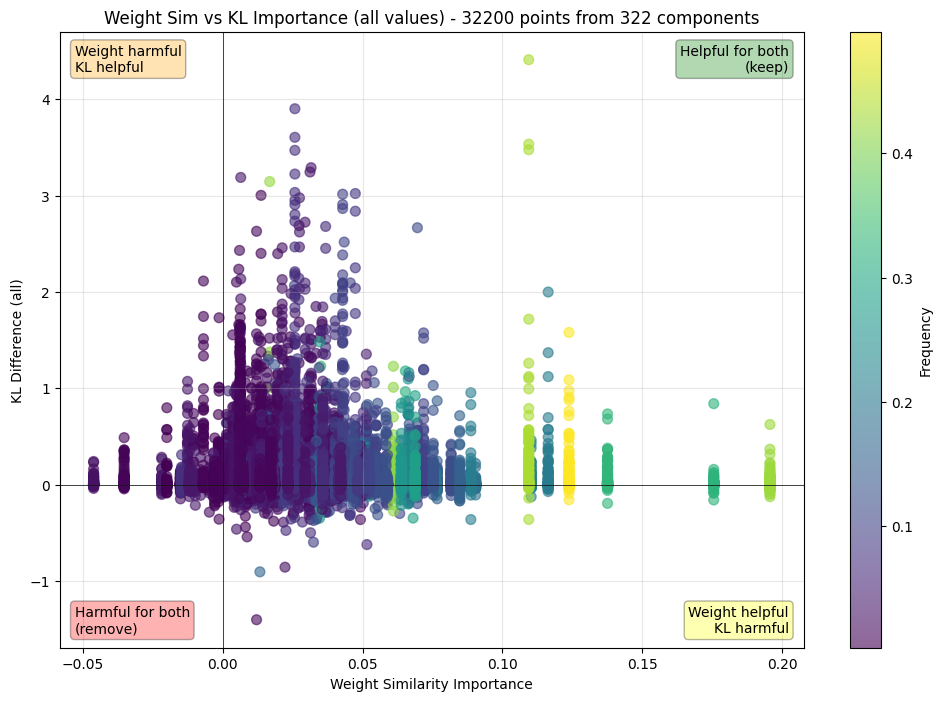

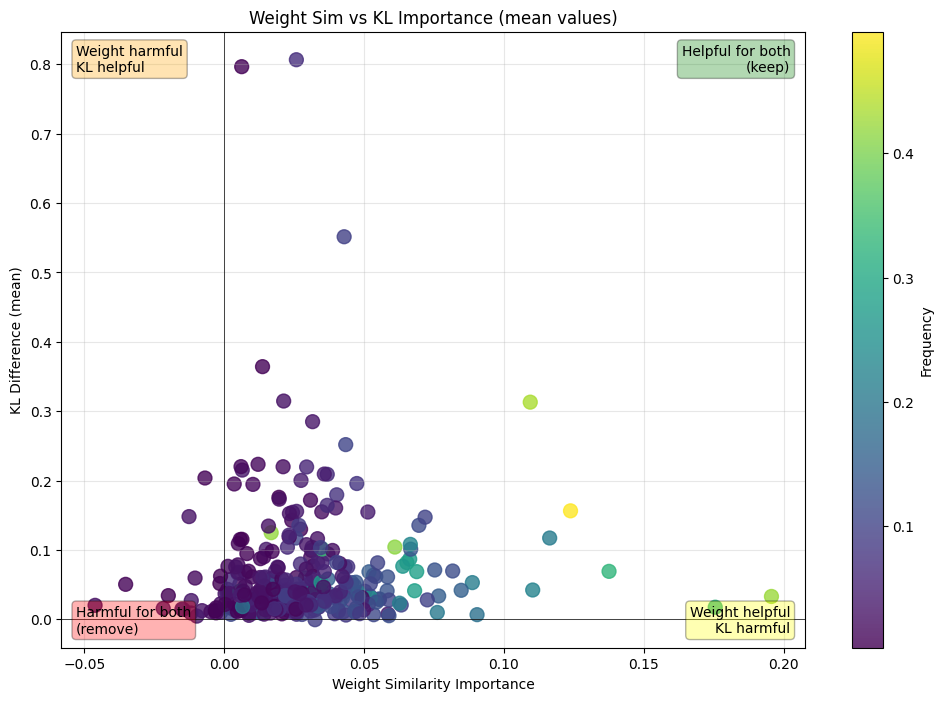

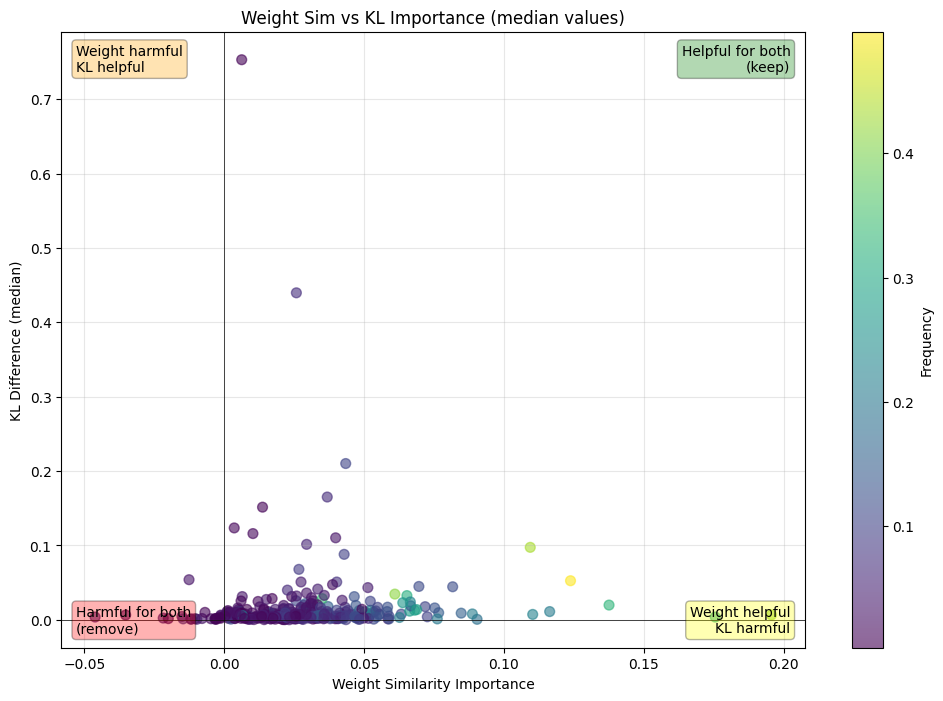

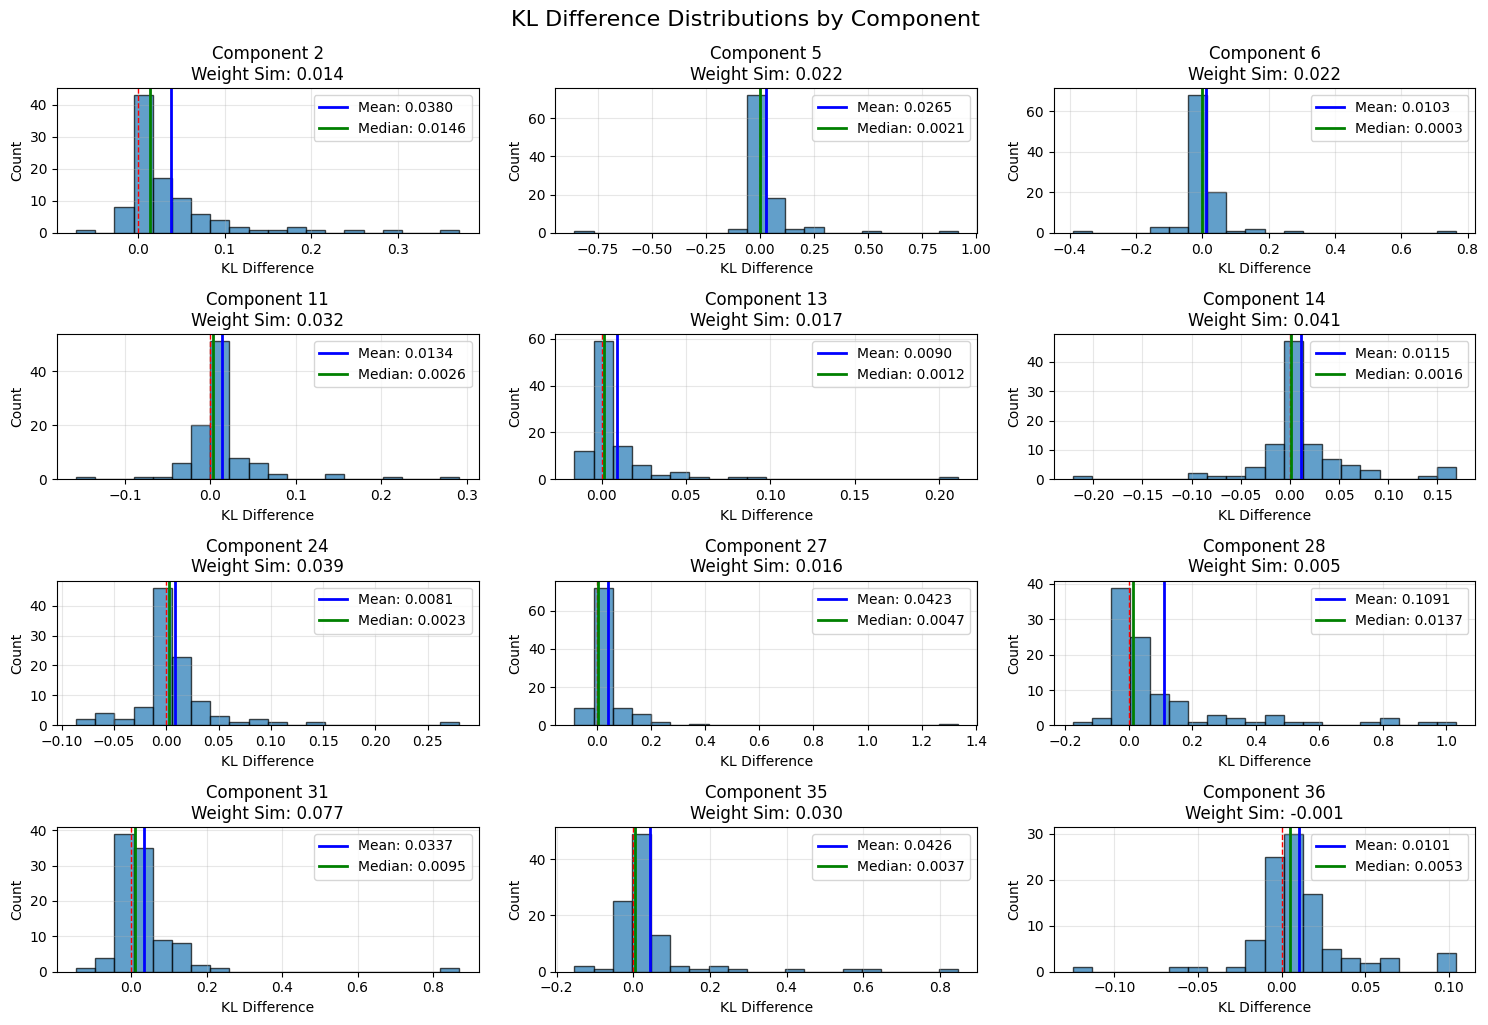

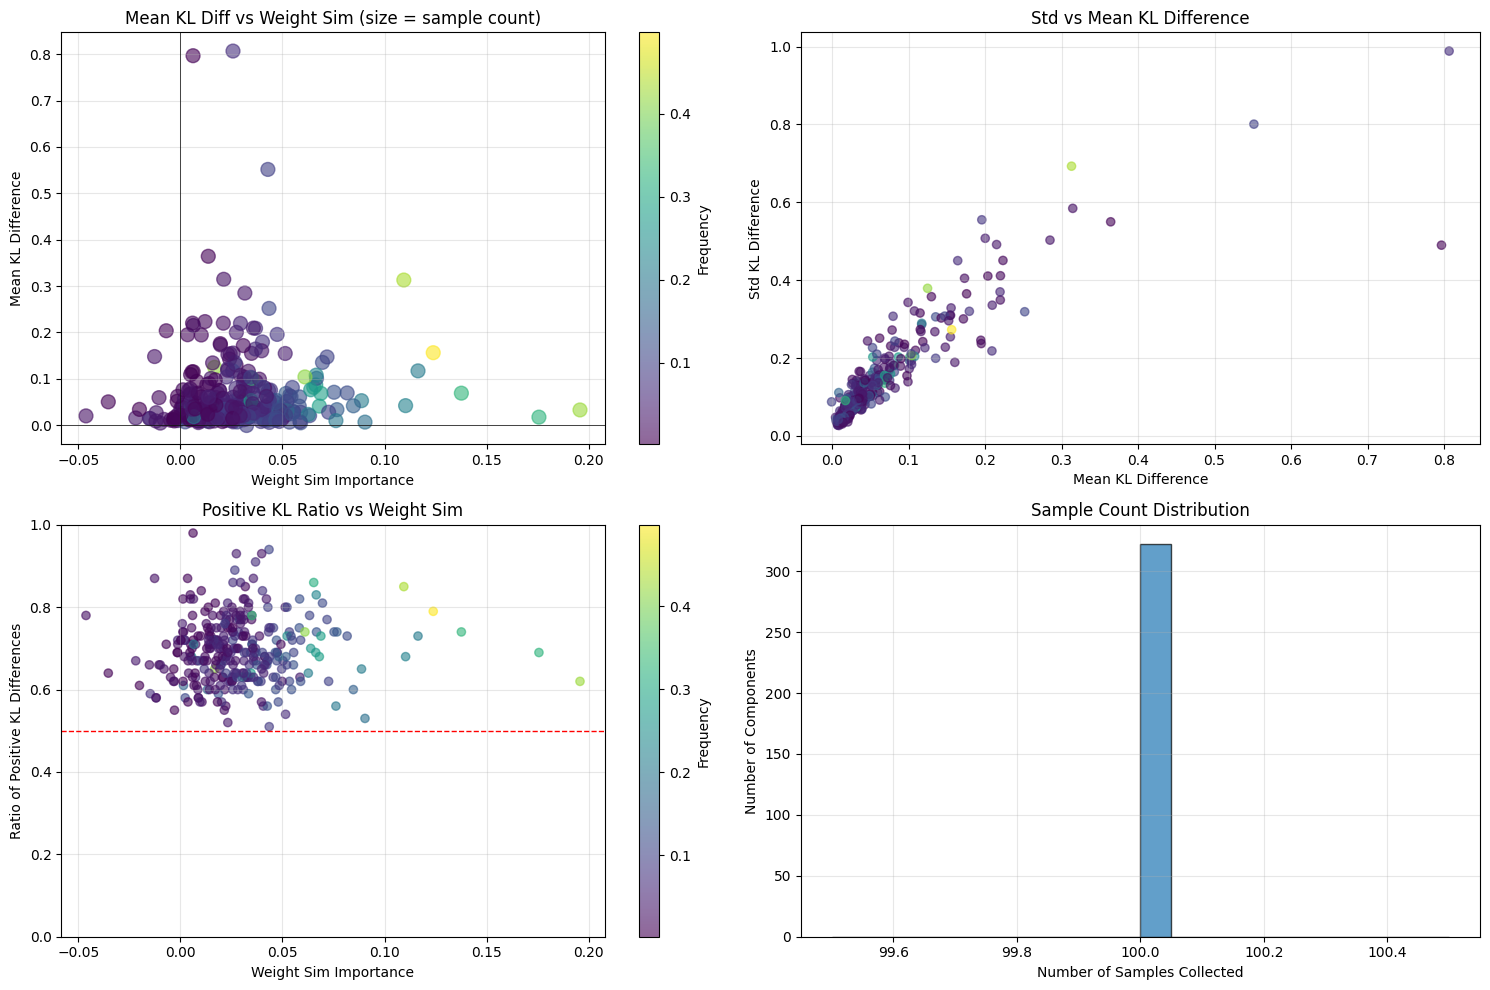

Component Distribution by Properties:
both_helpful: 22 components
both_harmful: 1 components
  Indices: [931]
weight_harmful_kl_helpful: 299 components
weight_helpful_kl_harmful: 0 components


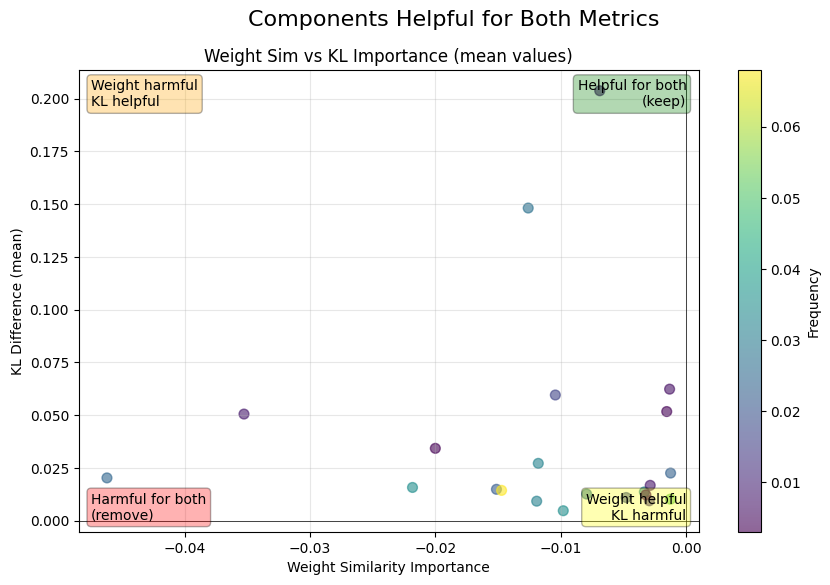

In [23]:
# %% [markdown]
# ## KL Analysis Visualizations

# %%
# Import plotting functions if not already imported
# from kl_analysis_functions import (
#     plot_weight_sim_vs_kl_importance,
#     plot_kl_difference_distributions,
#     plot_kl_statistics_summary
# )
# Or if using the main files:
# from plotting_utils import (
#     plot_weight_sim_vs_kl_importance,
#     plot_kl_difference_distributions,
#     plot_kl_statistics_summary
# )

# %%
# Plot 1: Weight sim vs KL importance (all individual points)
fig_kl_all = plot_weight_sim_vs_kl_importance(
    weight_sim_importance=results.weight_sim_importance,
    kl_differences=results.kl_differences,
    frequency=results.frequency,
    low_freq_indices=low_freq_indices,
    plot_type='all',  # Shows all individual KL measurements
    figsize=(12, 8),
    alpha=0.6,
    point_size=50
)
plt.show()  # or fig_kl_all.show()

# %%
# Plot 2: Weight sim vs KL importance (mean values per component)
fig_kl_mean = plot_weight_sim_vs_kl_importance(
    weight_sim_importance=results.weight_sim_importance,
    kl_differences=results.kl_differences,
    frequency=results.frequency,
    low_freq_indices=low_freq_indices,
    plot_type='mean',  # Shows mean KL difference per component
    figsize=(12, 8),
    alpha=0.8,
    point_size=100
)
plt.show()

# %%
# Plot 3: Weight sim vs KL importance (median values per component)
fig_kl_median = plot_weight_sim_vs_kl_importance(
    weight_sim_importance=results.weight_sim_importance,
    kl_differences=results.kl_differences,
    frequency=results.frequency,
    low_freq_indices=low_freq_indices,
    plot_type='median',  # Shows median KL difference per component
    figsize=(12, 8)
)
plt.show()

# %%
# Plot 4: KL difference distributions for top componentsm
# Shows histograms of KL differences for individual components
fig_kl_dist = plot_kl_difference_distributions(
    kl_differences=results.kl_differences,
    weight_sim_importance=results.weight_sim_importance,
    n_components=12  # Show top 12 components by sample count
)
plt.show()

# %%
# Plot 5: KL statistics summary (4-panel plot)
fig_kl_stats = plot_kl_statistics_summary(
    kl_statistics=results.kl_statistics,
    weight_sim_importance=results.weight_sim_importance,
    frequency=results.frequency,
    figsize=(15, 10)
)
plt.show()

# %% [markdown]
# ## Analyze Components by Quadrant

# %%
# Additional analysis: categorize components by their properties
quadrant_analysis = {
    'both_helpful': [],  # Negative weight sim, positive KL diff
    'both_harmful': [],  # Positive weight sim, negative KL diff
    'weight_harmful_kl_helpful': [],  # Positive weight sim, positive KL diff
    'weight_helpful_kl_harmful': []   # Negative weight sim, negative KL diff
}

for idx in low_freq_indices:
    idx_int = idx.item()
    if idx_int in kl_stats and kl_stats[idx_int]['count'] > 0:
        weight_sim = results.weight_sim_importance[idx].item()
        kl_mean = kl_stats[idx_int]['mean']
        
        if weight_sim < 0 and kl_mean > 0:
            quadrant_analysis['both_helpful'].append(idx_int)
        elif weight_sim > 0 and kl_mean < 0:
            quadrant_analysis['both_harmful'].append(idx_int)
        elif weight_sim > 0 and kl_mean > 0:
            quadrant_analysis['weight_harmful_kl_helpful'].append(idx_int)
        else:  # weight_sim < 0 and kl_mean < 0
            quadrant_analysis['weight_helpful_kl_harmful'].append(idx_int)

print("Component Distribution by Properties:")
for quadrant, indices in quadrant_analysis.items():
    print(f"{quadrant}: {len(indices)} components")
    if len(indices) > 0 and len(indices) <= 10:
        print(f"  Indices: {indices}")

# %%
# Optional: Create a summary plot showing only specific components
# For example, plot only the "both_helpful" components
if len(quadrant_analysis['both_helpful']) > 0:
    both_helpful_indices = torch.tensor(quadrant_analysis['both_helpful'])
    fig_helpful = plot_weight_sim_vs_kl_importance(
        weight_sim_importance=results.weight_sim_importance,
        kl_differences=results.kl_differences,
        frequency=results.frequency,
        low_freq_indices=both_helpful_indices,
        plot_type='mean',
        figsize=(10, 6)
    )
    fig_helpful.suptitle('Components Helpful for Both Metrics', fontsize=16)
    plt.show()

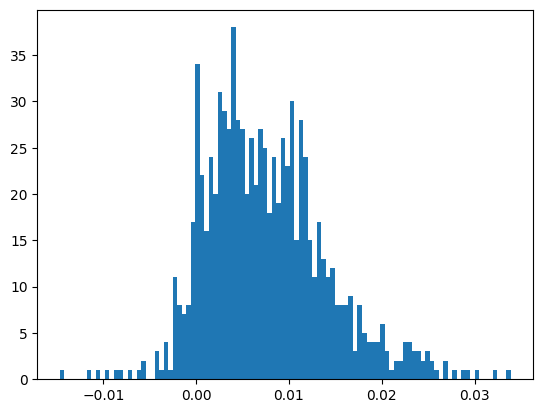

In [28]:
dead_weight_imp = results.weight_sim_importance[results.dead_mask]
plt.hist(dead_weight_imp, bins=100)
plt.show()

In [29]:
dead_weight_imp.sum()

tensor(6.5988)